In [1]:
# !pip install segmentation-models-pytorch
# !pip install torchmetrics
# !pip install mlflow[databricks]

In [2]:
import os

# Replace with your actual workspace URL and token
# os.environ['DATABRICKS_HOST'] = ""
# os.environ['DATABRICKS_TOKEN'] = ""


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms

import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# from torchmetrics.segmentation import DiceScore
# from torchmetrics.segmentation import MeanIoU

from tqdm import tqdm
import json

# Configurar el dispositivo (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map, alpha=0.45):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def show_overlay_with_labels(image, mask, label_dict, alpha=0.45, min_pixels=20):
    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    # image = cv2.imread(image_path)
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    overlay = create_color_overlay(mask, color_map, alpha=alpha)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.imshow(overlay, alpha=alpha)

    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        plt.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

    plt.title("Overlay con clases anatómicas")
    plt.axis("off")
    plt.show()

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# dataset = '/content/drive/MyDrive/Documentos/UniAndes/MAIA/2026-12/Proyecto Despluiegue de Soluciones/Proyecto/Scoliosis_Dataset'
# indice = pd.read_csv(os.path.join(dataset,'indice_dataset.csv'))

In [7]:
# dataset = 'Scoliosis_Dataset'
project_path = 'C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA'
dataset = os.path.join(project_path,'Scoliosis_Dataset')
indice = pd.read_csv(os.path.join(dataset,'indice_dataset.csv'))
data_split = 'C:/Users/juanm/PycharmProjects/Segmentacion_semantica_columna/notebooks/medsam_pipeline/data_splits\splits_estratificados_medsam.csv'
data_split = pd.read_csv(data_split)

In [8]:
with open(dataset+os.sep+'diccionario_etiquetas_T1_T12_L1_L5.json', 'r') as f:
    dic_labels = json.load(f)

color_label = dic_labels['mascara_multiclase_color_rgb']

In [9]:
# imagenes = pd.DataFrame(columns=['image_path', 'mask_path', 'id_paciente'])
# imagenes['image_path'] = dataset +os.sep + indice['grupo'] + os.sep + indice['imagen']
# imagenes['mask_path'] = dataset + os.sep + indice['ruta_mascara_multiclase_id_png']
# imagenes['id_paciente'] = indice['id_paciente']
# masks_path = masks_path.apple(dataset, indice['grupo'], indice['ruta_mascara_multiclase_id_png'])

In [10]:
# imagenes

In [11]:
train = data_split[data_split['split'] == 'train']
val = data_split[data_split['split'] == 'val']
test = data_split[data_split['split'] == 'test']

In [12]:
train_img = project_path+os.sep+train['image_relpath'].reset_index(drop=True)
train_mask = project_path+os.sep+train['mask_relpath'].reset_index(drop=True)
val_img = project_path+os.sep+val['image_relpath'].reset_index(drop=True)
val_mask = project_path+os.sep+val['mask_relpath'].reset_index(drop=True)
test_img = project_path+os.sep+test['image_relpath'].reset_index(drop=True)
test_mask = project_path+os.sep+test['mask_relpath'].reset_index(drop=True)

In [13]:
print(f'Train: {train_img.shape} Val: {val_img.shape} Test: {test_img.shape}')

Train: (174,) Val: (37,) Test: (38,)


In [41]:
MODEL_NAME = 'Unet++'
MODEL_PATH = 'modelos'+os.sep+MODEL_NAME+'patch'+'.pth'
SEED = 42
NUM_EPOCHS = 100
BATCH_SIZE = 4
PATIENCE = 20
STRIDE = 4
LR = 1e-3                   # Learning rate
WD = 0                   # Weight Decay
DROPOUT = None
PATCH_SIZE = 128
NUM_PATCHES = 8
CROP_RATIO = (0.1, 0.5)
STRIDE_RATIO = 4
IN_CHANNELS = 3
NUM_CLASSES = 18
TRAIN_ENCODER = True
CENTER_IMAGES = True
CLAHE = True
PERSPECTIVE = True

# LOSS = 'CrossEntropyLoss'
LOSS = 'CombinedLoss'
# LOSS = 'CombinedLossFocal'
# LOSS = 'DiceLoss'

# ENCODER_NAME = "resnet34"
# ENCODER_NAME = "resnet152"
ENCODER_NAME = "efficientnet-b7"
# ENCODER_NAME = "mit_b5"
# ENCODER_NAME = "tu-swinv2_small_window16_256"
# ENCODER_NAME = 'tu-sam2_hiera_large'

ENCODER_WEIGHTS = "imagenet"
# ENCODER_WEIGHTS = True
# ENCODER_WEIGHTS = None

# DECODER_ATTENTION = 'scse'
DECODER_ATTENTION = None

MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

if IN_CHANNELS == 1:
  MEAN = 0.44531356896770125
  STD = 0.2692461874154524

# CE_WEIGHT = 0.5
# DICE_WEIGHT = 0.5
# BASE_CHANNELS = 32

In [15]:
import mlflow

# Set the tracking URI to the Databricks workspace
mlflow.set_tracking_uri("databricks")

# Set the experiment name (must start with /Users/<email>/ or /Shared/)
experiment = mlflow.set_experiment("/"+MODEL_NAME+'_patch')

In [16]:
def compute_metrics(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    dice_scores = []
    iou_scores = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        intersection = np.sum(np.logical_and(pred_cls==1,target_cls==1))
        union = np.sum(np.logical_or(pred_cls==1,target_cls==1))

        dice = (2 * intersection + eps) / (pred_cls.sum() + target_cls.sum() + eps)
        iou = (intersection + eps) / (union + eps)

        dice_scores.append(dice)
        iou_scores.append(iou)

    if average:
        return np.mean(dice_scores), np.mean(iou_scores)
    else:
        return dice_scores, iou_scores

In [17]:
def compute_metrics_torch(preds, targets, num_classes=NUM_CLASSES, eps=1e-6, average=True):

    num_classes = num_classes

    # Convert targets to one-hot: [N, C, H, W]
    targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

    preds_one_hot = torch.nn.functional.one_hot(preds, num_classes).permute(0, 3, 1, 2).float()

    # Calculate intersection and cardinality
    dims = (2, 3) # Sum over batch, height, and width
    intersection = torch.sum(preds_one_hot * targets_one_hot, dim=dims)
    union = torch.sum(preds_one_hot + targets_one_hot, dim=dims) - intersection

    dice_score = (2. * intersection + eps) / (torch.sum(preds_one_hot, dim=dims) + torch.sum(targets_one_hot, dim=dims) + eps)
    iou_score = (intersection + eps) / (union + eps)

    if average:
        return dice_score.mean(dim=1), iou_score.mean(dim=1)
    else:
        return dice_score, iou_score

In [18]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [N, C, H, W], targets: [N, H, W]
        num_classes = logits.shape[1]
        probs = torch.nn.functional.softmax(logits, dim=1)

        # Convert targets to one-hot: [N, C, H, W]
        targets_one_hot = torch.nn.functional.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        # Calculate intersection and cardinality
        dims = (0, 2, 3) # Sum over batch, height, and width
        intersection = torch.sum(probs * targets_one_hot, dim=dims)
        union = torch.sum(probs + targets_one_hot, dim=dims)

        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_score.mean() # Return mean loss across classes

class CombinedLoss(nn.Module):
    def __init__(self, ce_weight=1, dice_weight=1):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        # self.dice = DiceLoss()
        self.dice = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

class CustomWeightedFocalLoss(nn.Module):
    def __init__(self, alpha_weights, gamma=2.0):
        super().__init__()
        # Esperamos un tensor 1D puro de tamaño [18]
        self.alpha_weights = alpha_weights
        self.gamma = gamma

    def forward(self, logits, targets):
        # 1. Calculamos la Cross Entropy SIN pesos para obtener la probabilidad real (pt)
        # reduction='none' mantiene la forma [Batch, H, W]
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)

        # 2. Aplicamos la fórmula base de Focal Loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        # 3. EL TRUCO MAGNÍFICO: Mapeo de pesos
        # targets contiene la clase correcta (0-17) de cada píxel.
        # Al hacer esto, extraemos el peso exacto para cada píxel individual,
        # creando un tensor 'pixel_weights' de forma idéntica: [Batch, H, W]
        pixel_weights = self.alpha_weights[targets]

        # 4. Multiplicamos de forma segura (ambos tensores son [Batch, H, W]) y promediamos
        weighted_focal_loss = focal_loss * pixel_weights

        return weighted_focal_loss.mean()

class CombinedLossFocal(nn.Module):
    def __init__(self, fl_weight=1, dice_weight=1):
        super().__init__()

        class_frequencies = np.array([1.0, 0.9718875502008032, 0.9879518072289156, 0.9919678714859438, 0.9879518072289156, 0.9759036144578314, 0.9558232931726908, 0.9317269076305221, 0.9116465863453815, 0.8955823293172691, 0.8714859437751004, 0.7991967871485943, 0.7590361445783133, 0.6546184738955824, 0.6265060240963856, 0.5502008032128514, 0.4819277108433735, 0.44176706827309237]
        )

        # 2. Calcular Alpha usando frecuencia inversa suavizada (Raíz cuadrada)
        # Agregamos un pequeño epsilon (1e-5) para evitar división por cero
        # alpha = 1.0 / np.sqrt(class_frequencies + 1e-5)
        #
        # # 3. Normalizar los alphas para que no den números gigantes que exploten el gradiente
        # alpha = alpha / np.sum(alpha)
        #
        # # alpha=torch.tensor(alpha, dtype=torch.float32).to(device)
        # alpha = torch.tensor(alpha, dtype=torch.float32).to(device)

        alpha = None

        self.focal = smp.losses.FocalLoss(mode='multiclass', alpha=None, gamma=2.0) if alpha == None else CustomWeightedFocalLoss(alpha_weights=alpha, gamma=2.0)
        self.dice = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.fl_weight = fl_weight
        self.dice_weight = dice_weight

    def forward(self, logits, targets):
        fl_loss = self.focal(logits, targets)
        dice_loss = self.dice(logits, targets)
        return self.fl_weight * fl_loss + self.dice_weight * dice_loss

In [19]:
class CustomSegmentationDataset(Dataset):
    def __init__(self, images_filenames, masks_filenames, transform=None, num_patches=NUM_PATCHES):
        self.images_filenames = images_filenames
        self.masks_filenames = masks_filenames
        self.transform = transform
        self.num_patches = num_patches

    def __len__(self):
        return len(self.images_filenames)

    def __getpath__(self, idx):
        return self.images_filenames[idx]

    def __getitem__(self, idx):
        image_path = self.images_filenames[idx]
        mask_path = self.masks_filenames[idx]
        try:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

            patches_img = []
            patches_mask = []
            for _ in range(self.num_patches):
                if self.transform:
                    augmented = self.transform(image=image, mask=mask)
                    p_image = augmented['image']
                    p_mask = augmented['mask']

                    patches_img.append(p_image)
                    patches_mask.append(p_mask)

            stacked_images = torch.stack(patches_img)
            stacked_masks = torch.stack(patches_mask)

        except:
            new_idx = (idx + 1)
            return self.__getitem__(new_idx)


        return stacked_images, stacked_masks

In [20]:
# --- TRANSFORMACIONES (Albumentations) ---
normalization = A.Normalize(mean=MEAN, std=STD)
clahe = A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)

# Transformaciones de entrenamiento: redimensionamiento, aumento de datos y normalización
train_transforms = []
# train_transforms += [A.OneOf([A.CropNonEmptyMaskIfExists(height=PATCH_SIZE, width=PATCH_SIZE, p=0.8), A.RandomCrop(height=PATCH_SIZE, width=PATCH_SIZE, p=0.2)], p=1)]
train_transforms += [A.RandomResizedCrop(size=(PATCH_SIZE,PATCH_SIZE), scale=CROP_RATIO, ratio=(1,1), p=1), A.GaussNoise(std_range=(0.05, 0.1), p=1.0)]


train_transforms+=[
    A.HorizontalFlip(p=0.2),
    A.Rotate(limit=(-10, 10), p=1.0),
    A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5)
]

if PERSPECTIVE:
    train_transforms.append(A.Perspective(scale=(0.01, 0.05)))
if CLAHE:
    train_transforms.append(clahe)

train_transforms.append(normalization)
train_transforms.append(ToTensorV2())

train_transform = A.Compose(train_transforms)
# train_transform = A.Compose([
#     A.LongestMaxSize(IMG_SIZE[0]),
#     A.PadIfNeeded(IMG_SIZE[0], IMG_SIZE[1]),
#     A.HorizontalFlip(p=0.2),
#     A.Rotate(limit=(-10, 10), p=1.0),
#     # A.VerticalFlip(p=0.5),
#     A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), p=0.5),
#     A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0),
#     # A.Normalize(mean=MEAN, std=STD),
#     # A.Resize(IMG_SIZE[0],IMG_SIZE[1]),
#     ToTensorV2(),
# ])

# Transformaciones de validación/prueba: solo redimensionamiento y normalización
val_transforms = []

# val_transforms += [A.CropNonEmptyMaskIfExists(height=PATCH_SIZE, width=PATCH_SIZE, p=1)]
val_transforms += [A.RandomResizedCrop(size=(PATCH_SIZE,PATCH_SIZE), scale=CROP_RATIO, ratio=(1,1), p=1)]
if CLAHE:
    val_transforms.append(clahe)

val_transforms.append(normalization)
val_transforms.append(ToTensorV2())

val_transform = A.Compose(val_transforms)

test_transforms = []
if CLAHE:
    test_transforms.append(clahe)
# test_transforms.append(ToTensorV2())
test_transforms.append(normalization)
test_transforms = A.Compose(test_transforms)



In [21]:

# --- DATALOADERS ---
train_dataset = CustomSegmentationDataset(train_img, train_mask, transform=train_transform)
val_dataset = CustomSegmentationDataset(val_img, val_mask, transform=val_transform)
test_dataset = CustomSegmentationDataset(test_img, test_mask, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# print(f"Imágenes de entrenamiento: {len(train_dataset)}")
# print(f"Imágenes de validación: {len(val_dataset)}")

torch.Size([3, 128, 128])


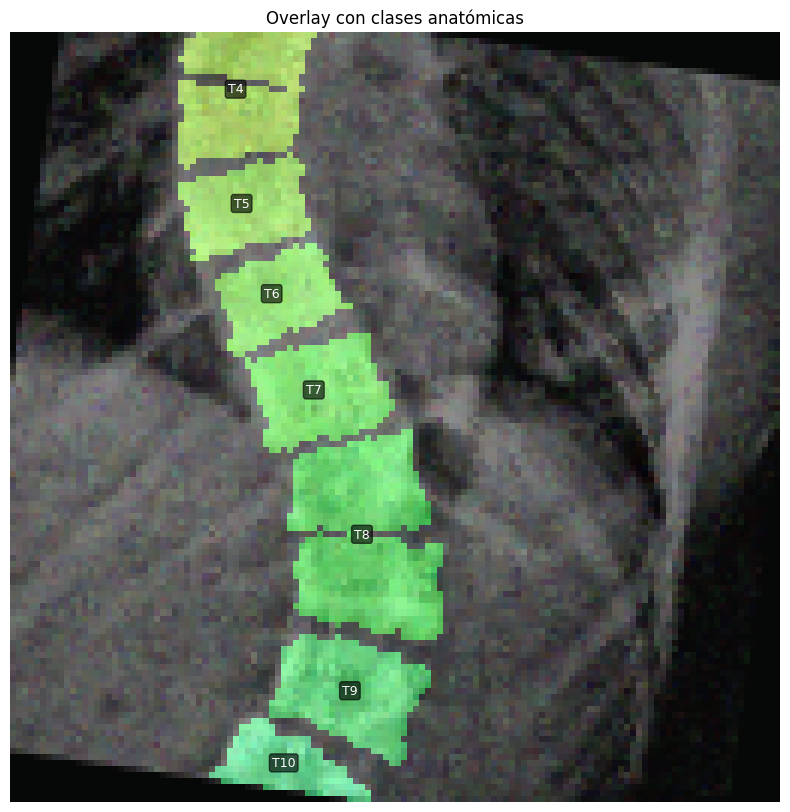

In [22]:
image, mask = train_dataset.__getitem__(10)
print(image[0].shape)
image = image[0].permute(1, 2, 0).cpu().numpy()
mask = mask[0].squeeze().cpu().numpy()
show_overlay_with_labels(image*STD+MEAN, mask, dic_labels)

torch.Size([8, 3, 128, 128])


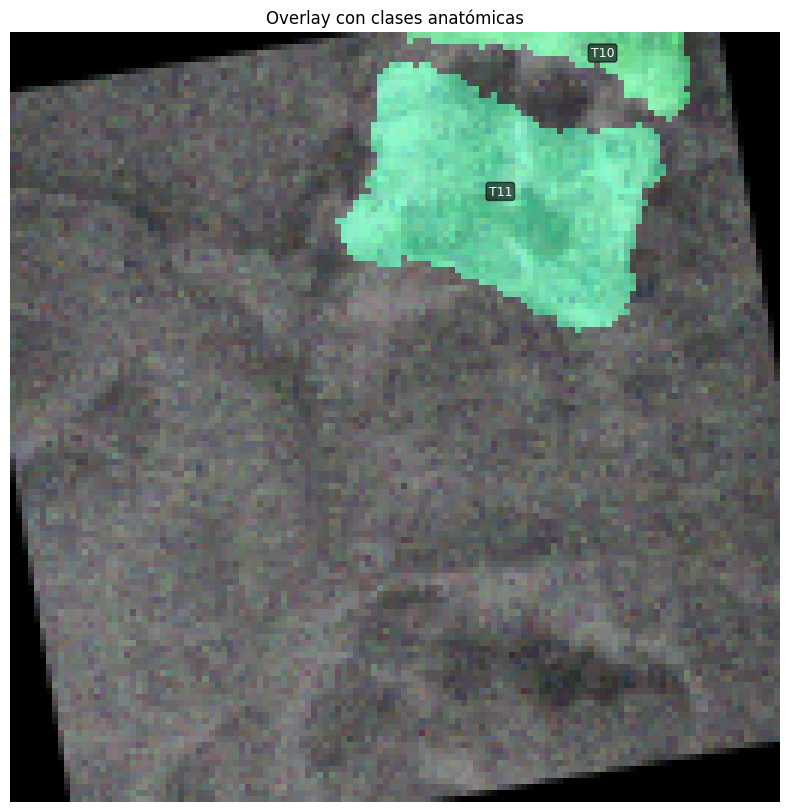

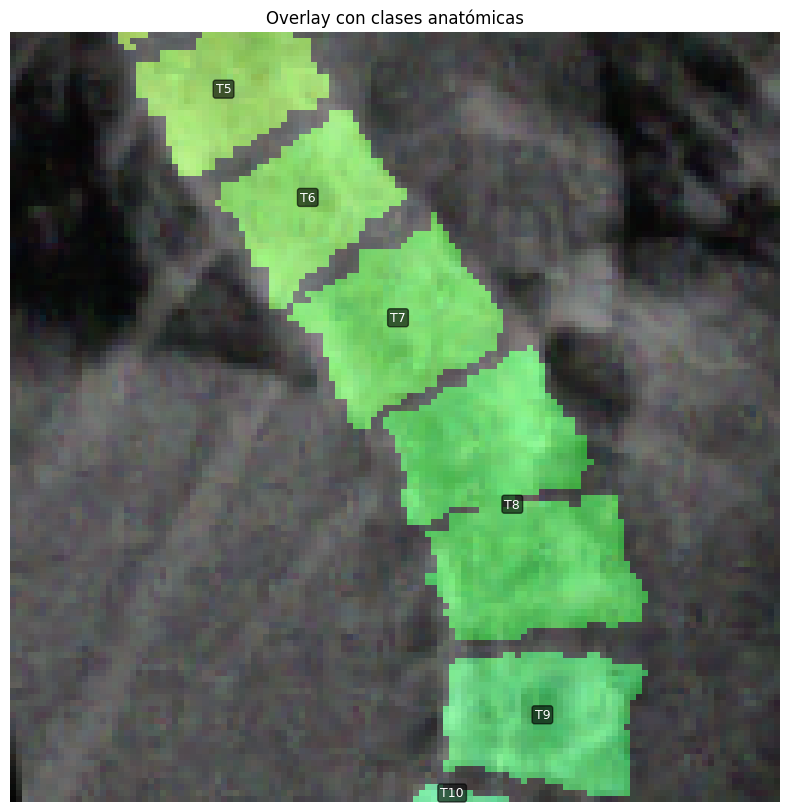

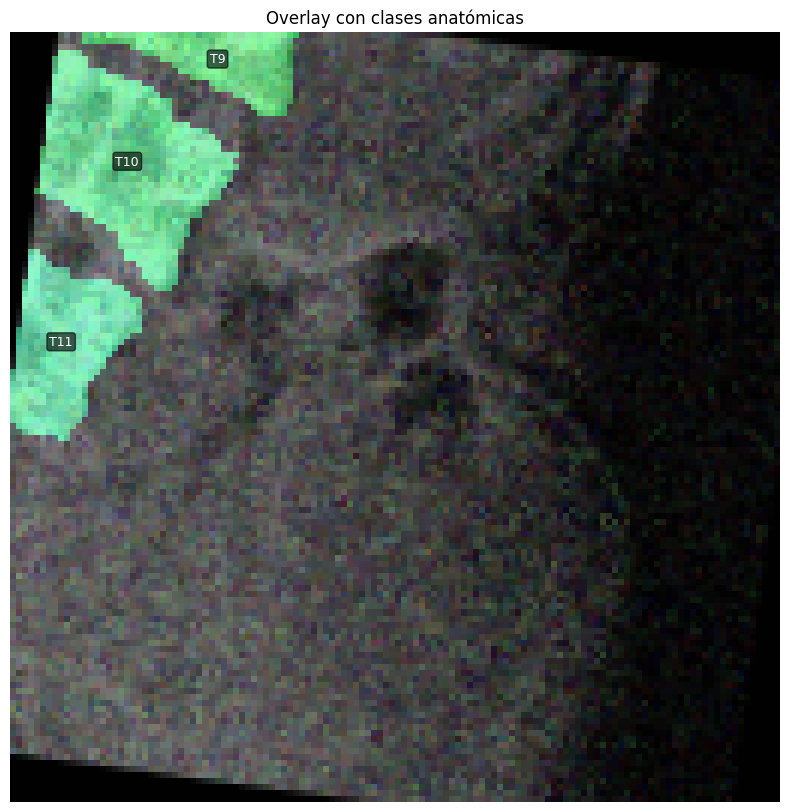

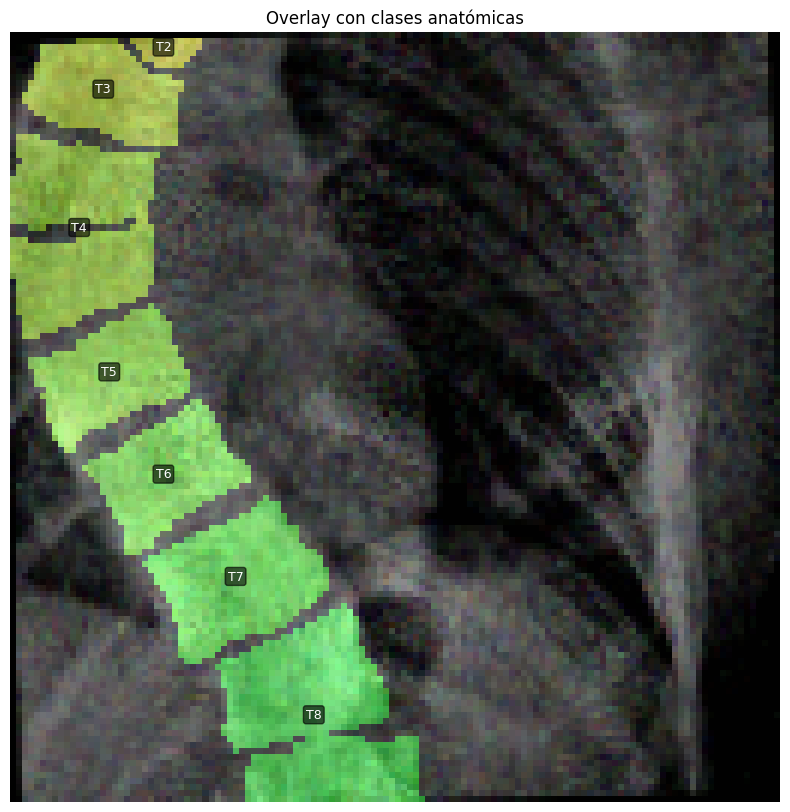

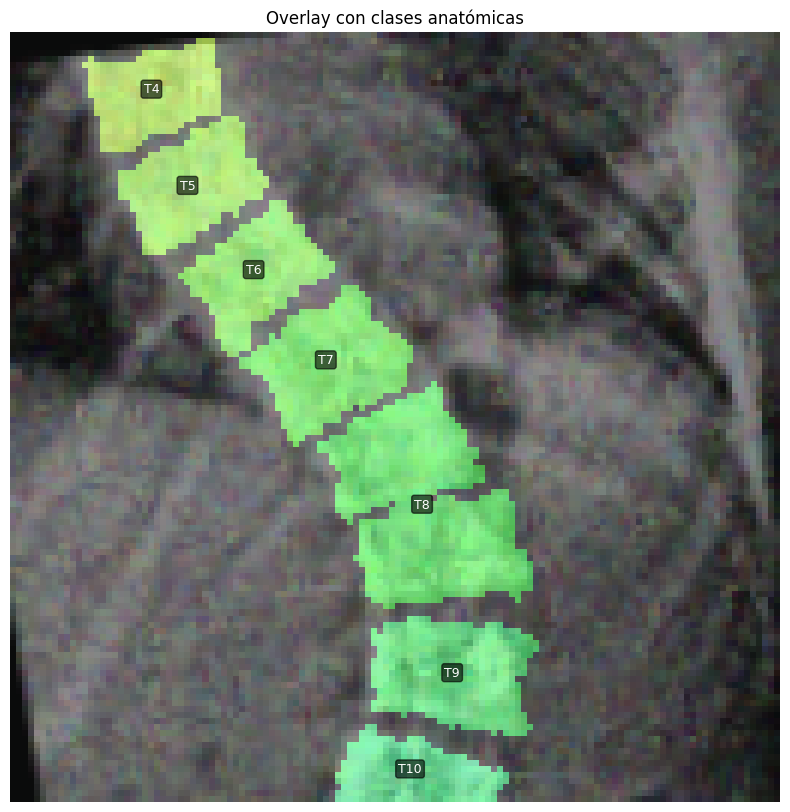

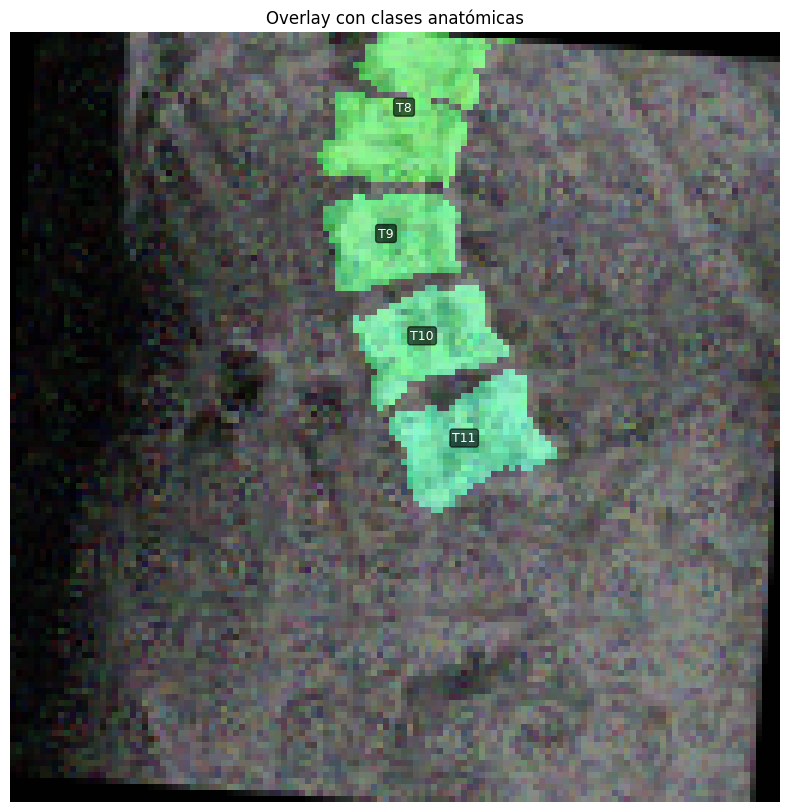

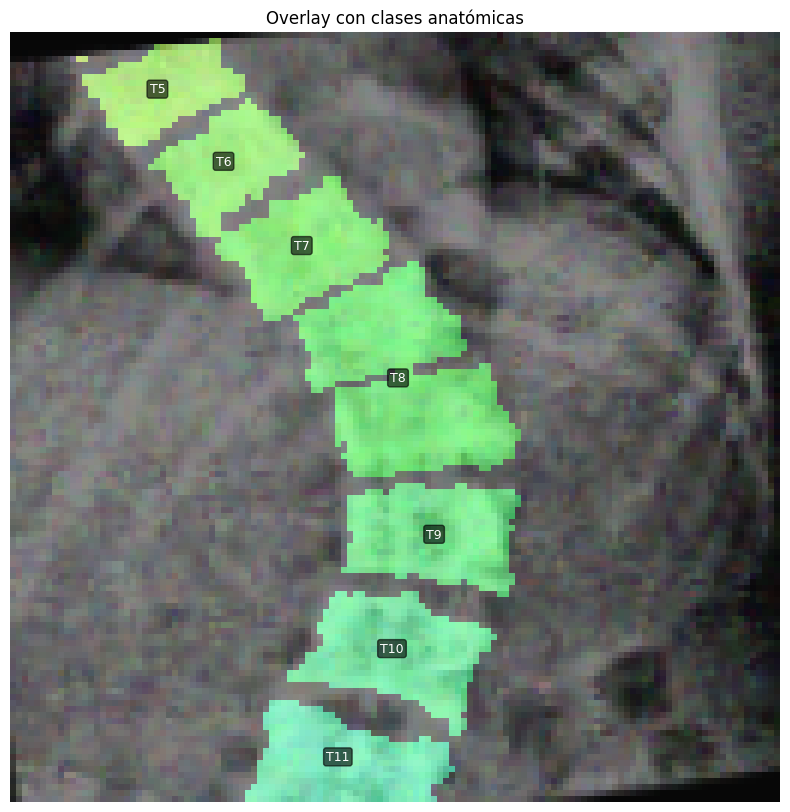

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999964237213].


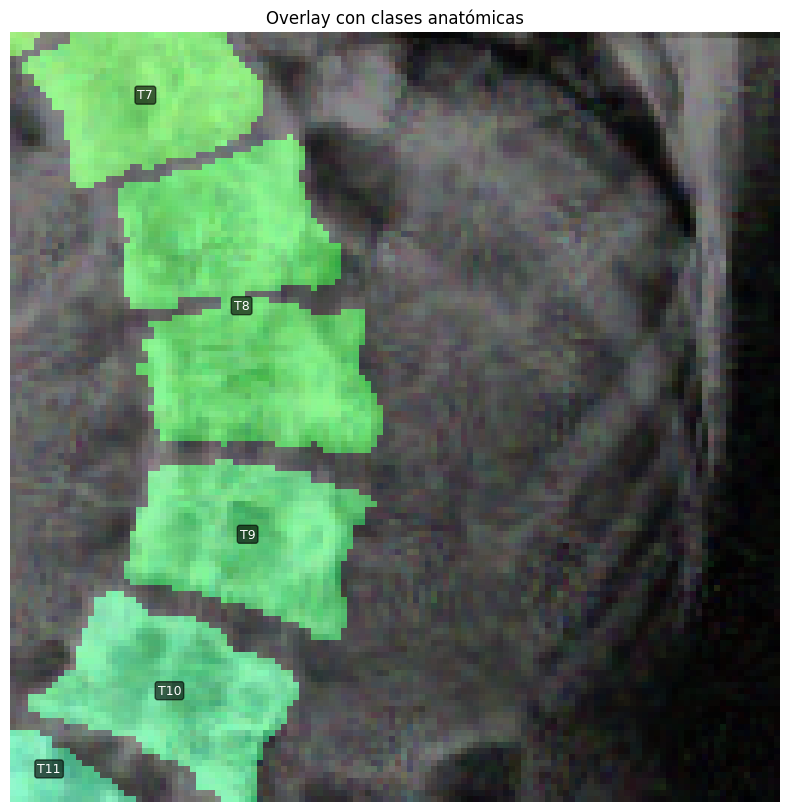

In [23]:
images, masks = train_dataset.__getitem__(10)
print(images.shape)
for image, mask in zip(images, masks):
    image = image.permute(1, 2, 0).cpu().numpy()
    mask = mask.squeeze().cpu().numpy()
    show_overlay_with_labels(image*STD+MEAN, mask, dic_labels)

In [24]:
if MODEL_NAME == 'Unet++':
    model = smp.UnetPlusPlus(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )
elif MODEL_NAME == 'Segformer':
    model = smp.Segformer(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        # aux_params={'classes':NUM_CLASSES, 'dropout':0.2}
    )
if MODEL_NAME == 'U-net':
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        decoder_attention_type = DECODER_ATTENTION,
        # pooling='max',
        # dropout = 0.5
    )

if MODEL_NAME == 'DeepLabV3+':
        model = smp.DeepLabV3Plus(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=IN_CHANNELS,
            classes=NUM_CLASSES,
            # decoder_attention_type = DECODER_ATTENTION,
            # pooling='max',
            # dropout = 0.5
        )

if DROPOUT is not None:
        model.segmentation_head = nn.Sequential(nn.Dropout2d(p=DROPOUT), model.segmentation_head)
model = model.to(device)

# Definir la función de pérdida y el optimizador
# Usamos BCEWithLogitsLoss porque el modelo no tiene una capa sigmoide final por defecto
# criterion = nn.BCEWithLogitsLoss()

if LOSS == 'CrossEntropyLoss':
    criterion = nn.CrossEntropyLoss()

elif LOSS == 'DiceLoss':
    # criterion =  DiceLoss()
    criterion = smp.losses.DiceLoss(mode='multiclass', from_logits=True)

elif LOSS == 'CombinedLoss':
    criterion = CombinedLoss()

elif LOSS == 'CombinedLossFocal':
        criterion = CombinedLossFocal()

elif LOSS == 'FocalLoss':
        criterion = smp.losses.FocalLoss(mode='multiclass', alpha=None, gamma=2.0)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)

if not TRAIN_ENCODER:
    for param in model.encoder.parameters():
        param.requires_grad = False


# Definir el scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',    # 'min' porque quieres que la pérdida disminuya
    factor=0.1,    # Reduce el LR al 10% (multiplica por 0.1)
    patience=PATIENCE,    # Espera 5 épocas sin mejora antes de reducir
    threshold=1e-4, # Cambio mínimo para considerar que hay mejora
)

In [25]:
with mlflow.start_run(experiment_id=experiment.experiment_id):

    train_losses = np.zeros(NUM_EPOCHS)
    val_losses = np.zeros(NUM_EPOCHS)
    val_dice = np.zeros(NUM_EPOCHS)
    best_epoch = 0
    best_metric = 0
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            B, N, C, H, W = images.shape
            images = images.view(B*N, C, H, W)
            masks = masks.view(B * N, H, W)

            images, masks = images.float().to(device), masks.long().to(device) # <--- Asegurar .long()


            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)

            # pred_mask = torch.argmax(outputs, dim=1)
            loss = criterion(outputs, masks)
            # loss = criterion(pred_mask, masks)

            # Backward pass y optimización
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validación simple
        model.eval()
        val_loss = 0.0
        dice_score_val = torch.empty((0,NUM_CLASSES))
        IoU_score_val = torch.empty((0,NUM_CLASSES))
        with torch.no_grad():
            for images, masks in val_loader:
                B, N, C, H, W = images.shape
                images = images.view(B*N, C, H, W)
                masks = masks.view(B * N, H, W).to(device)
                images, masks = images.float().to(device), masks.long().to(device)
                outputs = model(images)

                loss = criterion(outputs, masks)
                # loss = criterion(pred_mask, masks)
                val_loss += loss.item()

                pred_mask = torch.argmax(outputs, dim=1)

                dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
                dice_score_val = torch.cat((dice_score_val, dice), dim=0)
                IoU_score_val = torch.cat((IoU_score_val, IoU), dim=0)
            dice_score_val = torch.mean(dice_score_val)
            IoU_score_val = torch.mean(IoU_score_val)

        if dice_score_val > best_metric and epoch > 15:
            best_metric = dice_score_val
            torch.save(model.state_dict(), MODEL_PATH)
            best_epoch = epoch + 1

        train_losses[epoch] = train_loss / len(train_loader)
        val_losses[epoch] = val_loss / len(val_loader)

        scheduler.step(val_loss/len(val_loader))
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val DICE Score: {dice_score_val:.4f} | Val IoU Score: {IoU_score_val:.4f}")

    print('Best Epoch: ', best_epoch, ' Best metric: ', best_metric)

    mlflow.log_params({'best_epoch': best_epoch, 'EPOCHS': NUM_EPOCHS, 'SEED': SEED, 'BATCH_SIZE': BATCH_SIZE, 'PATIENCE': PATIENCE, 'LR': LR, 'WD': WD,'CROP_RATIO':CROP_RATIO, 'STRIDE_RATIO': STRIDE_RATIO ,'PATCH_SIZE': PATCH_SIZE,'NUM_PATCHES':NUM_PATCHES , 'IN_CHANNELS': IN_CHANNELS, 'TRAIN_ENCODER': TRAIN_ENCODER, 'CENTER_IMAGES': CENTER_IMAGES, 'CLAHE': CLAHE, 'PERSPECTIVE': PERSPECTIVE ,'LOSS': LOSS, 'ENCODER_NAME': ENCODER_NAME, 'DECODER_ATTENTION': DECODER_ATTENTION, 'DROPOUT': DROPOUT})

    mlflow.log_metric(f"val_mean_dice_score", dice_score_val)
    mlflow.log_metric(f"best_val_dice_score", dice_score_val)
    mlflow.pytorch.log_model(model, name=MODEL_NAME)

    for step, value in enumerate(train_losses):
        mlflow.log_metric('train_hist', value, step=step)
    for step, value in enumerate(val_losses):
        mlflow.log_metric('val_hist', value, step=step)


Epoch 1/100 | Train Loss: 2.3523 | Val Loss: 1.6272 | Val DICE Score: 0.6854 | Val IoU Score: 0.6808
Epoch 2/100 | Train Loss: 1.5910 | Val Loss: 1.4885 | Val DICE Score: 0.6727 | Val IoU Score: 0.6674
Epoch 3/100 | Train Loss: 1.5137 | Val Loss: 1.4282 | Val DICE Score: 0.6034 | Val IoU Score: 0.5956
Epoch 4/100 | Train Loss: 1.4786 | Val Loss: 1.3628 | Val DICE Score: 0.6110 | Val IoU Score: 0.6003
Epoch 5/100 | Train Loss: 1.4257 | Val Loss: 1.3555 | Val DICE Score: 0.5725 | Val IoU Score: 0.5604
Epoch 6/100 | Train Loss: 1.3966 | Val Loss: 1.4486 | Val DICE Score: 0.5234 | Val IoU Score: 0.5099
Epoch 7/100 | Train Loss: 1.3749 | Val Loss: 1.3465 | Val DICE Score: 0.5295 | Val IoU Score: 0.5137
Epoch 8/100 | Train Loss: 1.3632 | Val Loss: 1.3502 | Val DICE Score: 0.5530 | Val IoU Score: 0.5362
Epoch 9/100 | Train Loss: 1.3561 | Val Loss: 1.3191 | Val DICE Score: 0.5600 | Val IoU Score: 0.5437
Epoch 10/100 | Train Loss: 1.3245 | Val Loss: 1.2678 | Val DICE Score: 0.5697 | Val IoU Sco

2026/05/14 18:46:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/14 18:46:43 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/14 18:46:54 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_e

🏃 View run auspicious-mare-974 at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/1784634680320993/runs/0f9c78664dff4b75b417e85da4bdbefd
🧪 View experiment at: https://dbc-250dea69-0463.cloud.databricks.com/ml/experiments/1784634680320993


In [26]:
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

UnetPlusPlus(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 64, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          64, 64, kernel_size=(3, 3), stride=[1, 1], groups=64, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(64, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          64, 16, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          16, 64, kernel_size=(1, 1), stride=(1, 1)
          (static_padding

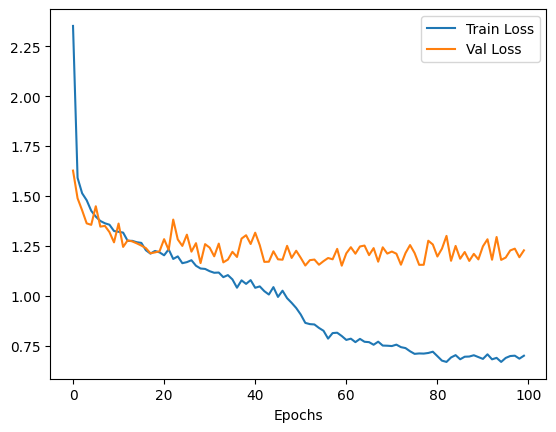

In [27]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel('Epochs')
plt.legend()

In [133]:
def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def draw_labels_on_axis(ax, mask, label_map, min_pixels=20):
    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        ax.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

def show_gt_vs_pred_with_labels_images(
    image,
    gt_mask,
    pred_mask,
    label_dict,
    alpha=0.45,
    min_pixels=20
):

    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    sample_dice, sample_IoU = compute_metrics(pred_mask, gt_mask, average=False)
    dice_score_mean, IoU_score_mean = compute_metrics(pred_mask, gt_mask)

    if image.shape[2] == 1:
        image_cmap = "gray"
    else:
        image_cmap = None

    # image = np.clip(image, 0, 1)
    image = image*STD+MEAN
    gt_overlay = create_color_overlay(gt_mask, color_map)
    pred_overlay = create_color_overlay(pred_mask, color_map)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(image, cmap=image_cmap)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(image, cmap=image_cmap)
    axes[1].imshow(gt_overlay, alpha=alpha)
    draw_labels_on_axis(axes[1], gt_mask, label_map, min_pixels=min_pixels)
    axes[1].set_title("Ground Truth con etiquetas")
    axes[1].axis("off")

    axes[2].imshow(image, cmap=image_cmap)
    axes[2].imshow(pred_overlay, alpha=alpha)
    draw_labels_on_axis(axes[2], pred_mask, label_map, min_pixels=min_pixels)
    axes[2].set_title(f"Predicción con etiquetas, Dice={dice_score_mean:.4f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    # print(f'Dice Score promedio: {dice_score_mean.numpy():.4f}')
    # print(f'Dice Score promedio: {dice_score_mean:.4f}')
    # print('Dice Score por clase: ')
    # for i,j in zip(dic_labels['mascara_multiclase_id_png'], sample_dice):
    #     # print(dic_labels['mascara_multiclase_id_png'][i],j.numpy())
    #     print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

In [167]:
import torch
import numpy as np
import torch.nn.functional as F
import cv2
from tqdm import tqdm
import scipy

def create_gaussian_window(patch_size, sigma=1.0):
    """
    Crea una matriz de pesos 2D con una distribución Gaussiana.
    Da más peso al centro del parche y menos a los bordes.
    """
    window_1d = scipy.signal.windows.gaussian(patch_size,sigma)
    window_2d = np.outer(window_1d,window_1d)
    return torch.from_numpy(window_2d).float()

def patch_based_inference(model, image, mask, patch_size, stride, num_classes, sigma, show_patches=False):
    """
    Realiza inferencia en una imagen grande usando ventanas deslizantes con solape y suavizado.

    image: Tensor [C, H_large, W_large] pre-procesado (normalizado).
    """
    model.eval()
    H_large, W_large, _ = image.shape

    # 1. Crear tensores vacíos en la GPU para acumular las predicciones y los pesos
    # Forma: [Num_Clases, H, W]
    # Usamos floats para acumular probabilidades
    accumulated_predictions = torch.zeros((num_classes, H_large, W_large)).to(device)
    accumulated_weights = torch.zeros((H_large, W_large)).to(device)

    # 2. Crear la ventana Gaussiana de suavizado
    gaussian_window = create_gaussian_window(patch_size, sigma).to(device)

    # 3. Bucle de Ventana Deslizante (Sliding Window)
    # Calculamos cuántos pasos dar en y y x
    y_steps = range(0, H_large - patch_size + 1, stride)
    x_steps = range(0, W_large - patch_size + 1, stride)

    # print(len(x_steps), W_large, patch_size,stride)

    # Asegurar que cubrimos el borde final si el stride no encaja perfecto
    # (Añadimos el último parche posible si no termina exactamente en el borde)

    if y_steps[-1] + patch_size < H_large:
        y_steps = list(y_steps) + [H_large - patch_size]
    if x_steps[-1] + patch_size < W_large:
        x_steps = list(x_steps) + [W_large - patch_size]

    # print(len(x_steps), W_large, patch_size,stride)
    with torch.no_grad():
        # Usamos tqdm para ver progreso ya que esto tarda
        # image = (image / 255.0 - MEAN) / STD
        # for y in tqdm(y_steps, desc="Procesando filas"):
        for y in y_steps:
            for x in x_steps:
                # Extaer el parche de la imagen grande

                # print(image_norm.shape)
                # HWC a CHW y convertir a Tensor
                patch = image[y:y+patch_size, x:x+patch_size, :]
                patch = cv2.resize(patch, (PATCH_SIZE, PATCH_SIZE))

                # transform = torchvision.transforms.ToTensor()
                # patch = transform(patch)
                patch = torch.from_numpy(patch)
                patch = patch.permute(2, 0, 1)
                # print(patch.shape)

                # Añadir dimensión de batch -> [1, C, H_patch, W_patch]
                patch_batch = patch.float().unsqueeze(0).to(device)
                # print(patch_batch.shape)

                # Inferencia del modelo (Logits) -> [1, 18, H_patch, W_patch]
                # trans_image = val_transform(image=image)['image'].float().unsqueeze(0).to(device)
                logits = model(patch_batch)

                if show_patches:
                    patched_mask = mask[y:y+patch_size, x:x+patch_size]
                    patched_mask = cv2.resize(patched_mask, (PATCH_SIZE, PATCH_SIZE))
                    pred_mask_patch = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
                    # print(patch.shape, patched_mask.shape, pred_mask_patch.shape)
                    show_gt_vs_pred_with_labels_images(
                    patch.permute(1, 2, 0).cpu().numpy(),
                    patched_mask,
                    pred_mask_patch,
                    label_dict=dic_labels,
                    alpha=0.45,
                    min_pixels=20
                )

                # pred_mask_patch = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
                # plt.figure()
                # plt.imshow((patch.permute(1, 2, 0).cpu().numpy())*STD + MEAN)
                # plt.imshow(patch.permute(1, 2, 0).cpu().numpy())
                # plt.figure()
                # plt.imshow(pred_mask_patch)
                # show_overlay_with_labels(patch.permute(1, 2, 0).cpu().numpy(), pred_mask_patch, dic_labels) # Plot patches preds
                # print(np.max(pred_mask_patch), np.min(pred_mask_patch))

                # Convertir logits a probabilidades (Softmax)
                # Esto es crucial para la fusión ponderada
                # probs = F.softmax(logits, dim=1).squeeze(0) # -> [18, H_patch, W_patch]
                probs = F.softmax(logits, dim=1) # -> [1, 18, H_patch, W_patch]
                probs = F.interpolate(probs, size=(patch_size, patch_size), mode='bilinear', align_corners=False).squeeze(0)

                # 4. Aplicar Fusión Ponderada en la GPU
                # Multiplicar las probabilidades de cada clase por el peso Gaussiano
                weighted_probs = probs * gaussian_window.unsqueeze(0) # Broadcatsing de canales

                # Acumular en la imagen grande
                accumulated_predictions[:, y:y+patch_size, x:x+patch_size] += weighted_probs

                # Acumular los pesos aplicados en esa zona para luego normalizar
                accumulated_weights[y:y+patch_size, x:x+patch_size] += gaussian_window

    # 5. Normalización Final
    # Dividir las probabilidades acumuladas por la suma de pesos en cada píxel
    # Usamos una pequeña constante (1e-5) para evitar división por cero en bordes extremos
    final_segmentation_probs = accumulated_predictions / (accumulated_weights.unsqueeze(0) + 1e-5)

    return final_segmentation_probs


def patch_inference(model, image, mask, patch_area = CROP_RATIO[1], stride=STRIDE_RATIO, num_classes=NUM_CLASSES, sigma=1.0, show_patches=False):
    x, y, _ = image.shape
    min_dim = min(x, y)
    patch_size = np.round(np.sqrt(patch_area*x*y)).astype(int)
    patch_size = min_dim if patch_size > min_dim else patch_size
    stride = np.round(patch_size/stride).astype(int)
    # print(f'Patch Size: {patch_size} | Stride: {stride}')

    probs_map = patch_based_inference(
    model,
    image,
    mask,
    patch_size,
    stride,
    num_classes,
    sigma,
    show_patches
    )
    pred_mask = torch.argmax(probs_map, dim=0).cpu().numpy() # -> [H, W] con valores 0-17
    # print(f"Forma de máscara final: {final_mask.shape}", f"Forma imagen original: {image.shape}")
    return pred_mask

In [ ]:
# best_mean_dice = 0
# best_sigma = 0
# for sigma in tqdm(np.linspace(1, 50, 10),desc='Realizando predicciones en parche para el set de validacion'):
#     mean_dice = 0
#     for idx in range(len(val_img)):
#         img_path = val_img[idx]
#         mask_path = val_mask[idx]
#         image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
#         mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#         image = test_transforms(image=image)['image']
#         pred_mask = patch_inference(model, image, mask, sigma=sigma)
#
#         if idx == 0:
#             show_gt_vs_pred_with_labels_images(
#             image,
#             mask,
#             pred_mask,
#             label_dict=dic_labels,
#             alpha=0.45,
#             min_pixels=20
#         )
#         # plt.figure()
#         # plt.imshow(cv2.resize(image*STD+MEAN,(pred_mask.shape[1],pred_mask.shape[0])))
#         # plt.figure()
#         # plt.imshow(pred_mask)
#         # plt.figure()
#         # plt.imshow(cv2.resize(mask,(pred_mask.shape[1],pred_mask.shape[0])))
#
#         dice, IoU = compute_metrics(pred_mask, mask)
#         mean_dice += dice
#
#     mean_dice = mean_dice/len(val_img)
#     print(f'Sigma: {sigma} | Mean Dice: {mean_dice:.4f}')
#
#     if best_mean_dice < mean_dice:
#         best_mean_dice = mean_dice
#         best_sigma = sigma
#
# print(f'Best Sigma: {best_sigma} | Best Dice: {best_mean_dice:.4f}')

In [143]:
# best_crop = 0
# best_global_mean_dice = 0
# best_global_sigma = 0
# for crop in tqdm(np.linspace(CROP_RATIO[0], CROP_RATIO[1], 11),desc='Gridsearch crop size y sigma'):
#     best_mean_dice = 0
#     best_sigma = 0
#     for sigma in tqdm(np.linspace(5, 50, 11),desc='Realizando predicciones en parche para el set de validacion'):
#         mean_dice = 0
#         for idx in range(len(val_img)):
#             img_path = val_img[idx]
#             mask_path = val_mask[idx]
#             image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
#             mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#             image = test_transforms(image=image)['image']
#             pred_mask = patch_inference(model, image, mask, patch_area=crop, sigma=sigma)
#
#             # if idx == 0:
#             #     show_gt_vs_pred_with_labels_images(
#             #     image,
#             #     mask,
#             #     pred_mask,
#             #     label_dict=dic_labels,
#             #     alpha=0.45,
#             #     min_pixels=20
#             # )
#
#             dice, IoU = compute_metrics(pred_mask, mask)
#             mean_dice += dice
#
#         mean_dice = mean_dice/len(val_img)
#         print(f'Current CropRatio: {crop} | Current Sigma: {sigma} | Mean Dice: {mean_dice:.4f}')
#
#         if best_mean_dice < mean_dice:
#             best_mean_dice = mean_dice
#             best_sigma = sigma
#
#     print(f'Current CropRatio: {crop} | Best Sigma: {best_sigma} | Mean Dice: {best_mean_dice:.4f}')
#
#     if best_global_mean_dice < best_mean_dice:
#         best_global_mean_dice = best_mean_dice
#         best_crop = crop
#         best_global_sigma = sigma
#
# print(f'Results --> Best Crop: {best_crop} |Best sigma: {best_global_sigma}| Best Dice: {best_global_mean_dice:.4f}')

Gridsearch crop size y sigma:   0%|          | 0/11 [00:00<?, ?it/s]
Realizando predicciones en parche para el set de validacion:   0%|          | 0/11 [00:00<?, ?it/s]
Realizando predicciones en parche para el set de validacion:   9%|▉         | 1/11 [03:12<32:00, 192.07s/it]

Current CropRatio: 0.1 | Current Sigma: 5.0 | Mean Dice: 0.3731



Realizando predicciones en parche para el set de validacion:  18%|█▊        | 2/11 [06:14<27:57, 186.39s/it]

Current CropRatio: 0.1 | Current Sigma: 9.5 | Mean Dice: 0.3812



Realizando predicciones en parche para el set de validacion:  27%|██▋       | 3/11 [09:16<24:35, 184.45s/it]

...

Current CropRatio: 0.5 | Current Sigma: 41.0 | Mean Dice: 0.4389



Realizando predicciones en parche para el set de validacion:  91%|█████████ | 10/11 [05:04<00:30, 30.47s/it]

Current CropRatio: 0.5 | Current Sigma: 45.5 | Mean Dice: 0.4399



Realizando predicciones en parche para el set de validacion: 100%|██████████| 11/11 [05:35<00:00, 30.50s/it]
Gridsearch crop size y sigma: 100%|██████████| 11/11 [2:11:38<00:00, 718.02s/it]

Current CropRatio: 0.5 | Current Sigma: 50.0 | Mean Dice: 0.4466
Current CropRatio: 0.5 | Best Sigma: 36.5 | Mean Dice: 0.4466
Results --> Best Crop: 0.5 |Best sigma: 50.0| Best Dice: 0.4606


In [ ]:
SIGMA = best_global_sigma

best_crop = 0.26
SIGMA = 36.5

In [154]:
# best_mean_dice = 0
# best_stride = 0
# for stride in tqdm(np.linspace(2,6,3),desc='Busqueda stride'):
#     for idx in range(len(val_img)):
#         img_path = val_img[idx]
#         mask_path = val_mask[idx]
#         image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
#         mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
#         image = test_transforms(image=image)['image']
#         pred_mask = patch_inference(model, image, mask, stride=stride, patch_area=best_crop, sigma=SIGMA)
#
#         # if idx == 0:
#         #     show_gt_vs_pred_with_labels_images(
#         #     image,
#         #     mask,
#         #     pred_mask,
#         #     label_dict=dic_labels,
#         #     alpha=0.45,
#         #     min_pixels=20
#         # )
#
#         dice, IoU = compute_metrics(pred_mask, mask)
#         mean_dice += dice
#
#     mean_dice = mean_dice/len(val_img)
#     print(f'Current Stride: {stride} | Mean Dice: {mean_dice:.4f}')
#
#     if best_mean_dice < mean_dice:
#         best_mean_dice = mean_dice
#         best_stride = stride
#
# print(f'Results --> Best Stride: {best_stride}| Best Dice: {best_mean_dice:.4f}')

Busqueda stride:  33%|███▎      | 1/3 [00:31<01:03, 31.83s/it]

Current Stride: 2.0 | Mean Dice: 0.4525


Busqueda stride:  67%|██████▋   | 2/3 [01:39<00:53, 53.13s/it]

Current Stride: 4.0 | Mean Dice: 0.4711


Busqueda stride: 100%|██████████| 3/3 [03:23<00:00, 67.69s/it]

Current Stride: 6.0 | Mean Dice: 0.4624
Results --> Best Stride: 4.0| Best Dice: 0.4711


In [155]:
# STRIDE=best_stride
STRIDE=4

In [34]:
# Predicciones dle modelo usando parches
dice_score_test = np.zeros(NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            # print(image.shape)
            N, C, H, W = image.shape
            image, mask = image.float().to(device), mask.long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).squeeze(0).cpu()
            # print(image.shape)
            for image, mask, pred_mask in zip(image, mask, pred_mask):
                # print(image.shape)
                dice, IoU = compute_metrics(pred_mask.cpu().numpy(), mask.to(torch.long).cpu().numpy(), average=False)
            dice_score_test += dice

dice_score_test = dice_score_test/len(test_dataset)

for i,j in zip(dic_labels['mascara_multiclase_id_png'], dice_score_test):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

background 0.9630
T1 0.9598
T2 0.7580
T3 0.6743
T4 0.6507
T5 0.5463
T6 0.5150
T7 0.4999
T8 0.4940
T9 0.4187
T10 0.4946
T11 0.4072
T12 0.5580
L1 0.5967
L2 0.7136
L3 0.6928
L4 0.7811
L5 0.8660


Text(0, 0.5, 'mean DICE score')

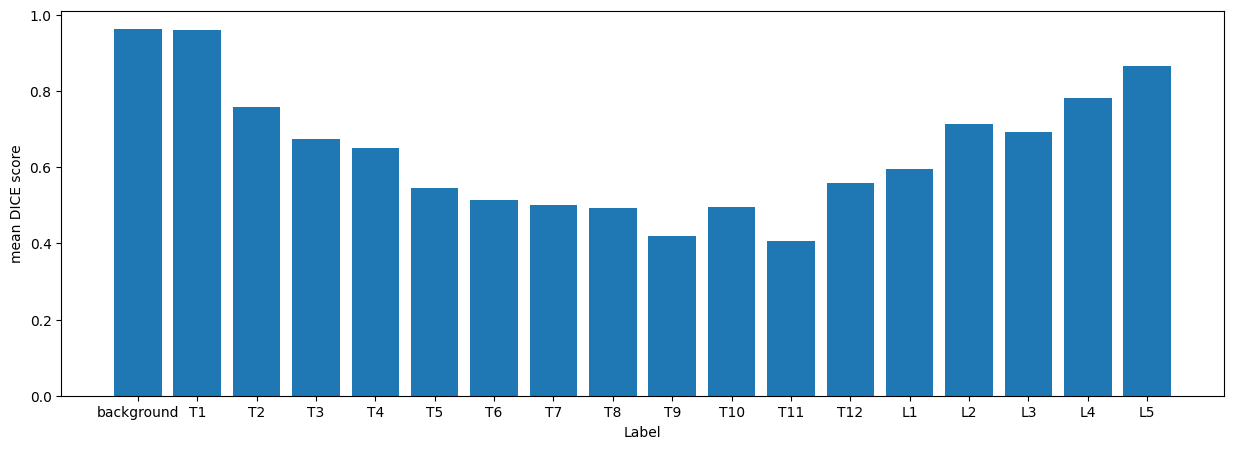

In [35]:
x = range(len(dice_score_test))
f, ax = plt.subplots()
ax.bar(x, dice_score_test)
ax.set_xticks(x)
labels = [dic_labels['mascara_multiclase_id_png'][i] for i  in dic_labels['mascara_multiclase_id_png']]
ax.set_xticklabels(labels)
ax.figure.set_size_inches(15, 5)
ax.set_xlabel('Label')
ax.set_ylabel('mean DICE score')

In [156]:
# Predicciones del modelo para la imagen reconstruida
dice_score_test = np.zeros(NUM_CLASSES)
model.eval()
for idx in range(len(test_img)):
        img_path = test_img[idx]
        mask_path = test_mask[idx]
        image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        image = test_transforms(image=image)['image']
        pred_mask = patch_inference(model, image, mask, patch_area=best_crop, stride=STRIDE, sigma=SIGMA)
        # print(image.shape)
        dice, IoU = compute_metrics(pred_mask, mask, average=False)
        dice_score_test += dice

dice_score_test = dice_score_test/len(test_img)

for i,j in zip(dic_labels['mascara_multiclase_id_png'], dice_score_test):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

background 0.9806
T1 0.7197
T2 0.6010
T3 0.4238
T4 0.3412
T5 0.2745
T6 0.2679
T7 0.2402
T8 0.2000
T9 0.1779
T10 0.2811
T11 0.2759
T12 0.3413
L1 0.4092
L2 0.4063
L3 0.5097
L4 0.6470
L5 0.6945


Text(0, 0.5, 'mean DICE score')

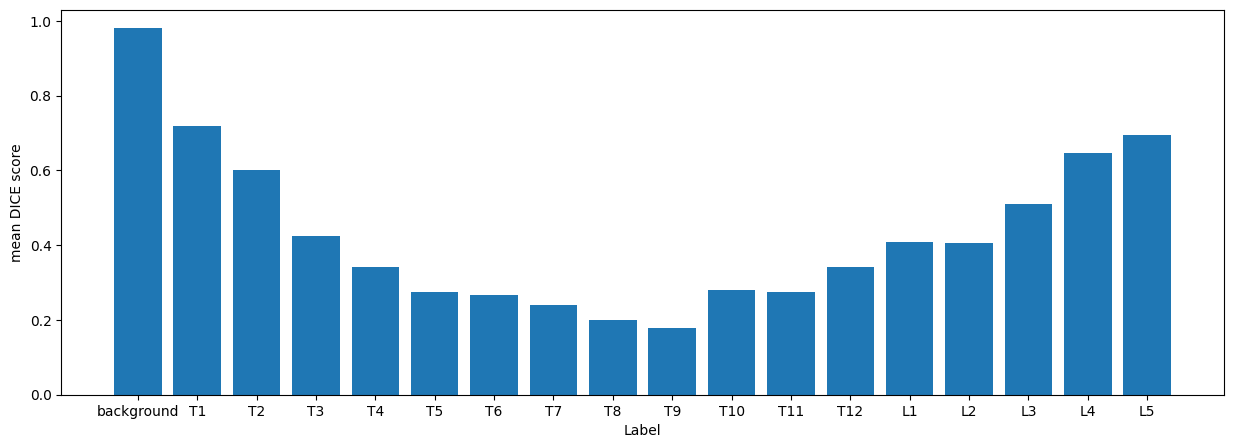

In [157]:
x = range(len(dice_score_test))
f, ax = plt.subplots()
ax.bar(x, dice_score_test)
ax.set_xticks(x)
labels = [dic_labels['mascara_multiclase_id_png'][i] for i  in dic_labels['mascara_multiclase_id_png']]
ax.set_xticklabels(labels)
ax.figure.set_size_inches(15, 5)
ax.set_xlabel('Label')
ax.set_ylabel('mean DICE score')

In [36]:
# Pruebas funcion compute_metrics_torch con el dataset test
dice_score_test = torch.zeros(NUM_PATCHES, NUM_CLASSES)
model.eval()
with torch.no_grad():
    for idx in range(len(test_dataset)):
            image, mask = test_dataset[idx]
            image, mask = image.float().to(device), mask.long().to(device)
            outputs = model(image)
            pred_mask = torch.argmax(outputs, dim=1).cpu()
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), mask.to(torch.long).cpu(), average=False)
            dice_score_test += dice.squeeze(0)

dice_score_test = dice_score_test/len(test_dataset)
print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')


for i,j in zip(dic_labels['mascara_multiclase_id_png'], torch.mean(dice_score_test, dim=0)):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

Mean Dice Score: 0.6687
background 0.9676
T1 0.9489
T2 0.7790
T3 0.7155
T4 0.6689
T5 0.5910
T6 0.5162
T7 0.4994
T8 0.4798
T9 0.4632
T10 0.4803
T11 0.5203
T12 0.5972
L1 0.6541
L2 0.6892
L3 0.7415
L4 0.8364
L5 0.8891


In [37]:
# Pruebas funcion compute_metrics_torch con el dataloader test
dice_score_test = torch.empty((0,18))
with torch.no_grad():
        for images, masks in test_loader:
            B, N, C, H, W = images.shape
            images = images.view(B*N, C, H, W)
            masks = masks.view(B * N, H, W)
            images, masks = images.float().to(device), masks.long().to(device)
            # print(images.shape, masks.shape)
            outputs = model(images)
            pred_mask = torch.argmax(outputs, dim=1)
            dice, IoU = compute_metrics_torch(pred_mask.cpu(), masks.to(torch.long).cpu(), average=False)
            # print(dice.shape)
            dice_score_test = torch.cat((dice_score_test, dice), dim=0)

print(f'Mean Dice Score: {torch.mean(dice_score_test):.4f}')
mean_dice_score = torch.mean(dice_score_test, dim=0).numpy()

for i,j in zip(dic_labels['mascara_multiclase_id_png'], mean_dice_score):
    print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')

Mean Dice Score: 0.6730
background 0.9688
T1 0.9342
T2 0.7870
T3 0.7103
T4 0.6296
T5 0.5675
T6 0.5326
T7 0.5113
T8 0.5114
T9 0.4795
T10 0.4743
T11 0.5380
T12 0.5848
L1 0.6425
L2 0.7095
L3 0.7805
L4 0.8490
L5 0.9037


In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

def build_color_map_from_json(label_dict):
    color_map_raw = label_dict["mascara_multiclase_color_rgb"]
    return {int(k): tuple(v) for k, v in color_map_raw.items()}

def build_label_map_from_json(label_dict):
    label_map_raw = label_dict["mascara_multiclase_id_png"]
    return {int(k): v for k, v in label_map_raw.items()}

def create_color_overlay(mask, color_map):
    h, w = mask.shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        overlay[mask == class_id] = color

    return overlay

def get_class_centroid(mask, class_id):
    ys, xs = np.where(mask == class_id)
    if len(xs) == 0 or len(ys) == 0:
        return None
    cx = int(np.mean(xs))
    cy = int(np.mean(ys))
    return cx, cy

def draw_labels_on_axis(ax, mask, label_map, min_pixels=20):
    unique_vals = np.unique(mask)

    for class_id in unique_vals:
        if class_id == 0:
            continue

        region = (mask == class_id)
        if region.sum() < min_pixels:
            continue

        centroid = get_class_centroid(mask, class_id)
        if centroid is None:
            continue

        x, y = centroid
        class_name = label_map.get(int(class_id), str(class_id))

        ax.text(
            x, y, class_name,
            fontsize=9,
            ha="center",
            va="center",
            color="white",
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2")
        )

def show_gt_vs_pred_with_labels(
    model,
    dataset,
    device,
    idx,
    patch_idx,
    label_dict,
    alpha=0.45,
    min_pixels=20
):
    model.eval()

    label_map = build_label_map_from_json(label_dict)
    color_map = build_color_map_from_json(label_dict)

    print(dataset.__getpath__(idx))

    sample = dataset[idx]
    if sample is None:
        print(f"No se pudo cargar la muestra {idx}")
        return

    image_tensor, gt_mask = sample
    image_tensor = image_tensor[patch_idx]
    gt_mask = gt_mask[patch_idx]
    image_batch = image_tensor.float().unsqueeze(0).to(device)

    with torch.no_grad():
        if device.type == "cuda":
            with torch.amp.autocast(device_type="cuda"):
                logits = model(image_batch)
        else:
            logits = model(image_batch)
    # print(logits)
    pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu()

    # dice_score = DiceScore(num_classes=NUM_CLASSES, average="none", input_format='index')
    # dice_score_mean = DiceScore(num_classes=NUM_CLASSES, average="macro", input_format='index')
    # dice_score_mean = dice_score_mean(pred_mask, gt_mask.to(torch.long).cpu())
    # sample_dice = dice_score(pred_mask, gt_mask.to(torch.long).cpu())

    pred_mask = pred_mask.numpy()
    gt_mask = gt_mask.cpu().numpy()

    sample_dice, sample_IoU = compute_metrics(pred_mask, gt_mask, average=False)
    dice_score_mean, IoU_score_mean = compute_metrics(pred_mask, gt_mask)

    image = image_tensor.cpu().numpy()
    if image.shape[0] == 1:
        image = image.squeeze(0)
        image_cmap = "gray"
    else:
        image = np.transpose(image, (1, 2, 0))
        image_cmap = None

    # image = np.clip(image, 0, 1)
    image = image*STD+MEAN
    gt_overlay = create_color_overlay(gt_mask, color_map)
    pred_overlay = create_color_overlay(pred_mask, color_map)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(image, cmap=image_cmap)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    axes[1].imshow(image, cmap=image_cmap)
    axes[1].imshow(gt_overlay, alpha=alpha)
    draw_labels_on_axis(axes[1], gt_mask, label_map, min_pixels=min_pixels)
    axes[1].set_title("Ground Truth con etiquetas")
    axes[1].axis("off")

    axes[2].imshow(image, cmap=image_cmap)
    axes[2].imshow(pred_overlay, alpha=alpha)
    draw_labels_on_axis(axes[2], pred_mask, label_map, min_pixels=min_pixels)
    axes[2].set_title("Predicción con etiquetas")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    gt_classes = np.unique(gt_mask)
    pred_classes = np.unique(pred_mask)
    # print(f'Dice Score promedio: {dice_score_mean.numpy():.4f}')
    print(f'Dice Score promedio: {dice_score_mean:.4f}')
    print('Dice Score por clase: ')
    for i,j in zip(dic_labels['mascara_multiclase_id_png'], sample_dice):
        # print(dic_labels['mascara_multiclase_id_png'][i],j.numpy())
        print(dic_labels['mascara_multiclase_id_png'][i],f'{j:.4f}')
    # print(f"DICE Score: {sample_dice:.4f}")

    # print("\nClases presentes en Ground Truth:")
    # for c in gt_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")
    #
    # print("\nClases presentes en Predicción:")
    # for c in pred_classes:
    #     name = label_map.get(int(c), f"Clase {c}")
    #     print(f"  {c} → {name}")

2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


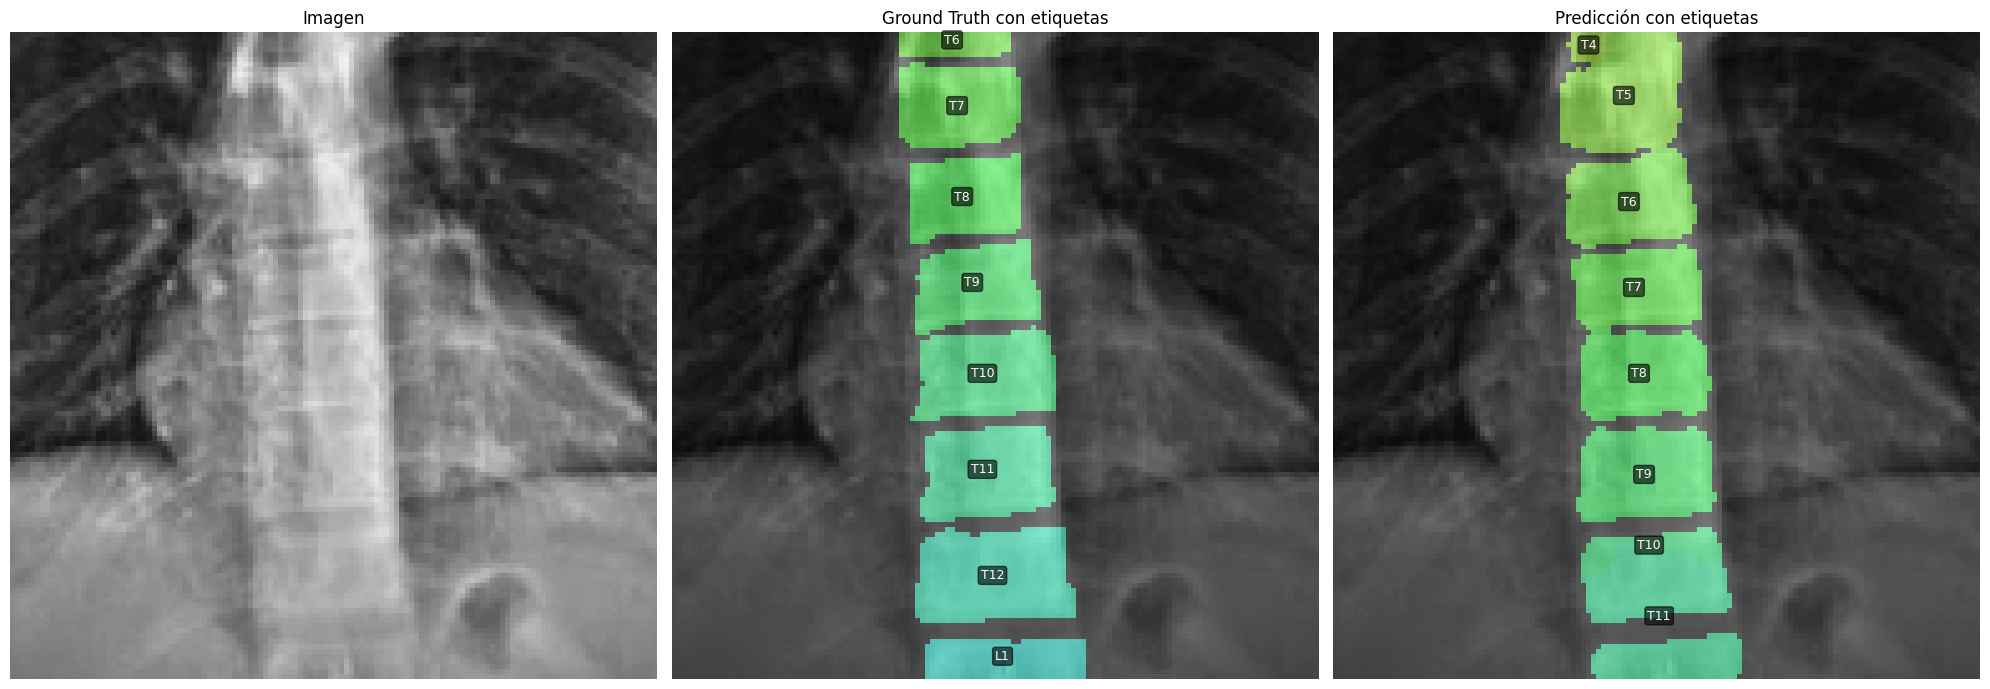

Dice Score promedio: 0.4435
Dice Score por clase: 
background 0.9832
T1 1.0000
T2 1.0000
T3 1.0000
T4 0.0000
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


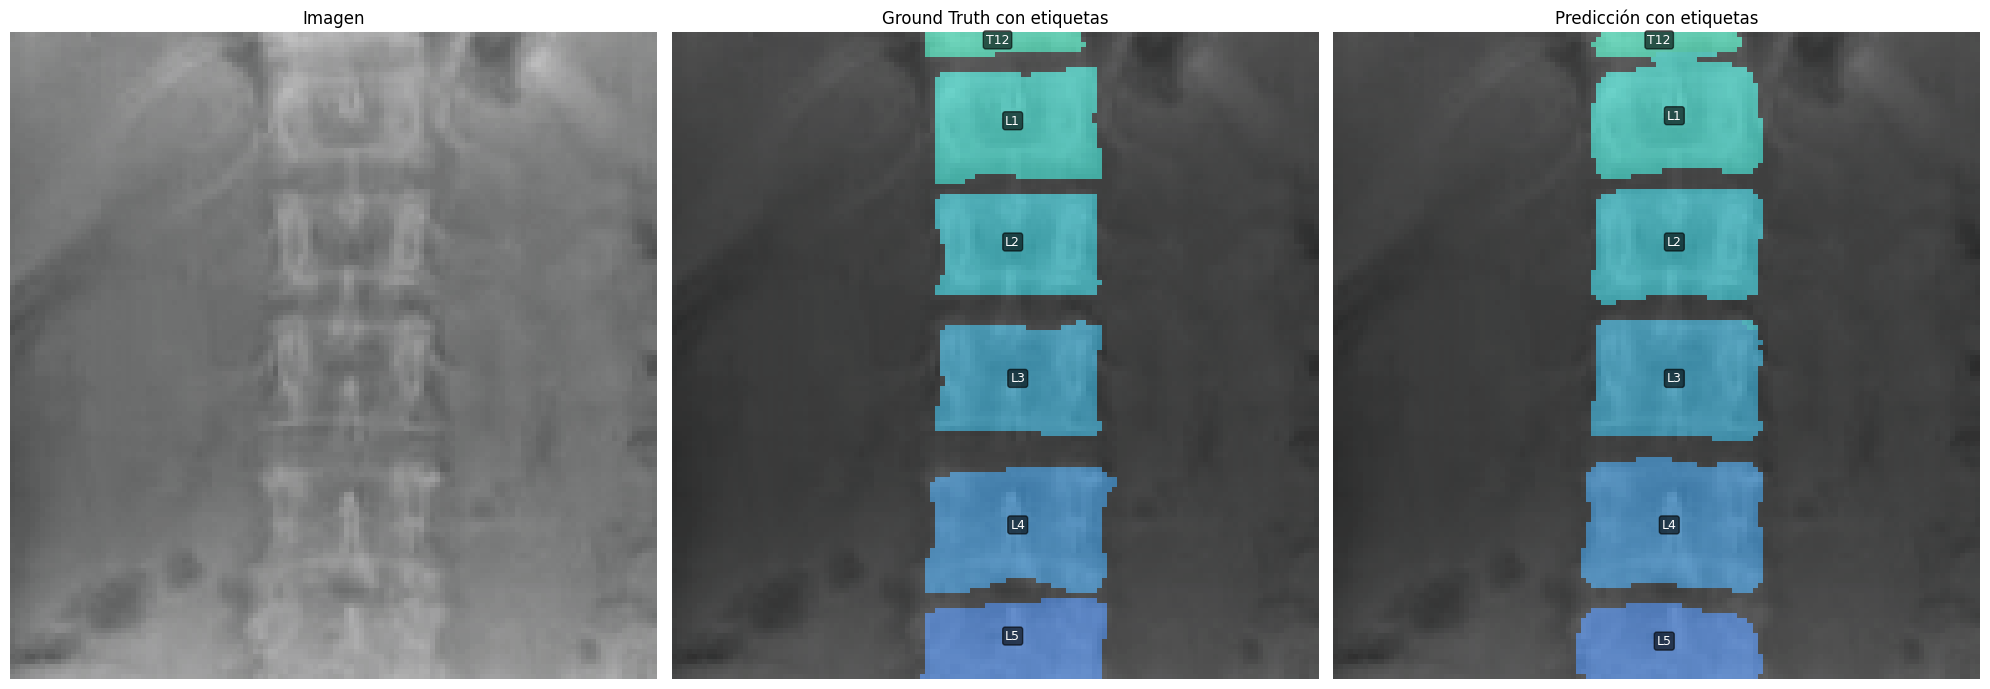

Dice Score promedio: 0.9746
Dice Score por clase: 
background 0.9793
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 0.9509
L1 0.9125
L2 0.9375
L3 0.9301
L4 0.9191
L5 0.9137
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


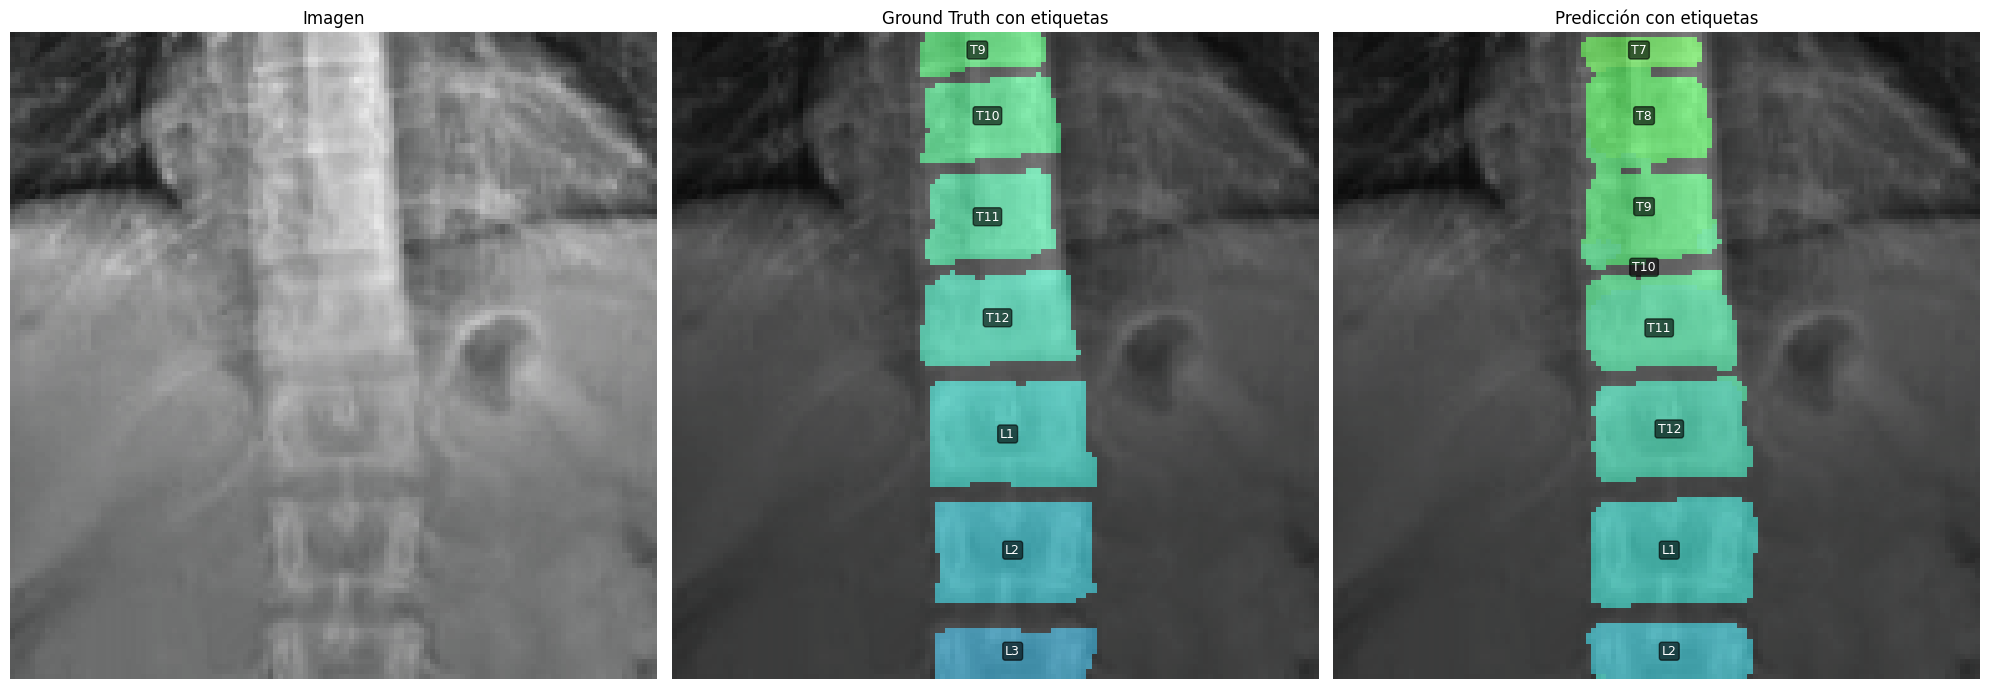

Dice Score promedio: 0.4991
Dice Score por clase: 
background 0.9839
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.0000
L2 0.0000
L3 0.0000
L4 1.0000
L5 1.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


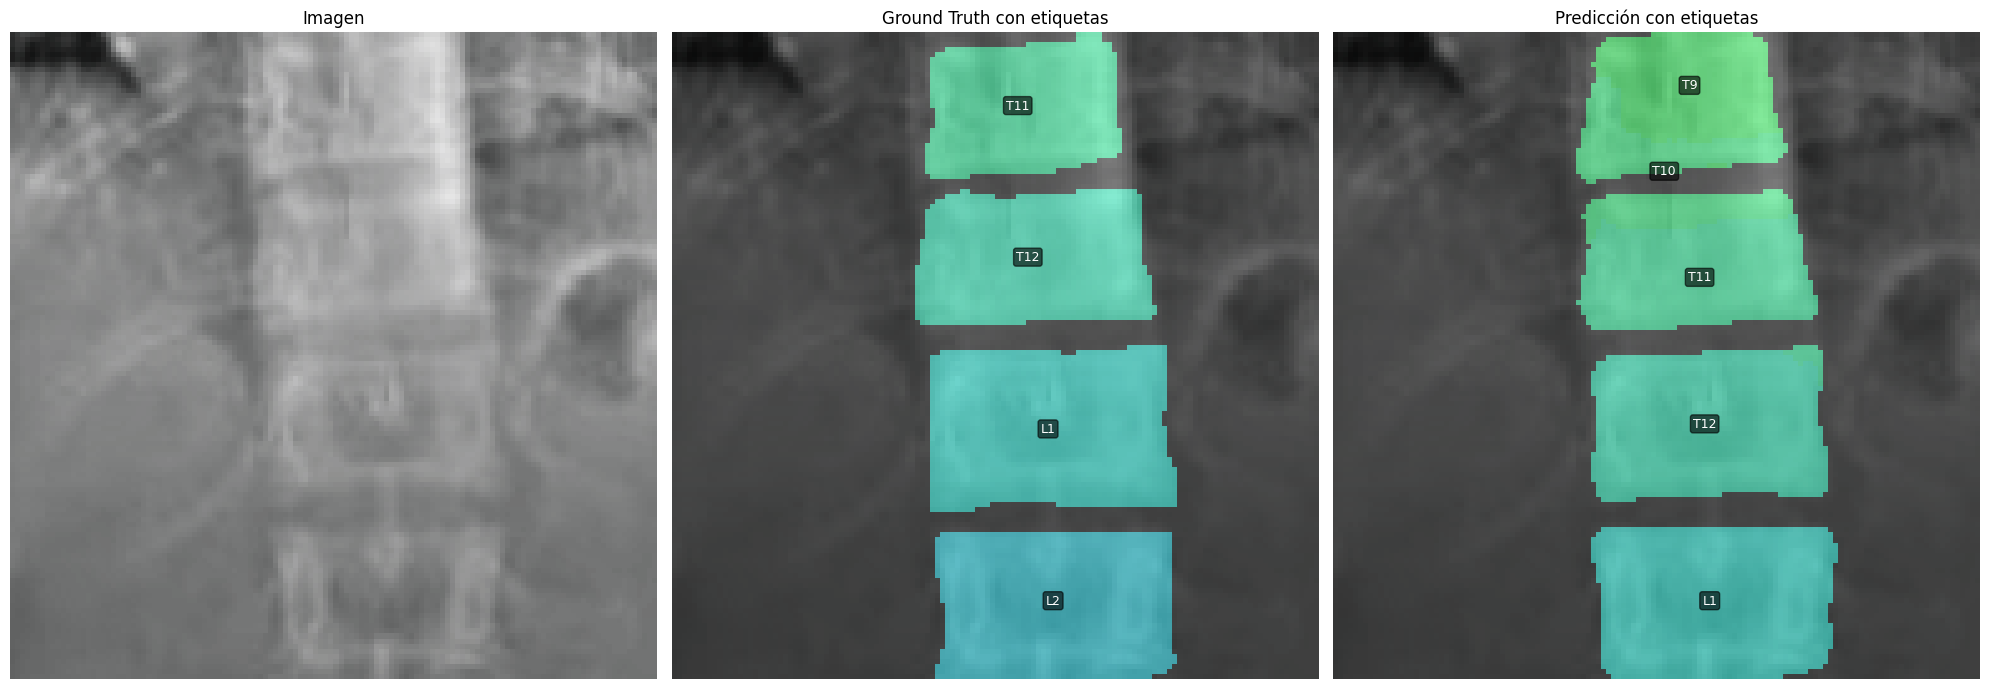

Dice Score promedio: 0.6655
Dice Score por clase: 
background 0.9788
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 0.0000
L2 0.0000
L3 1.0000
L4 1.0000
L5 1.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


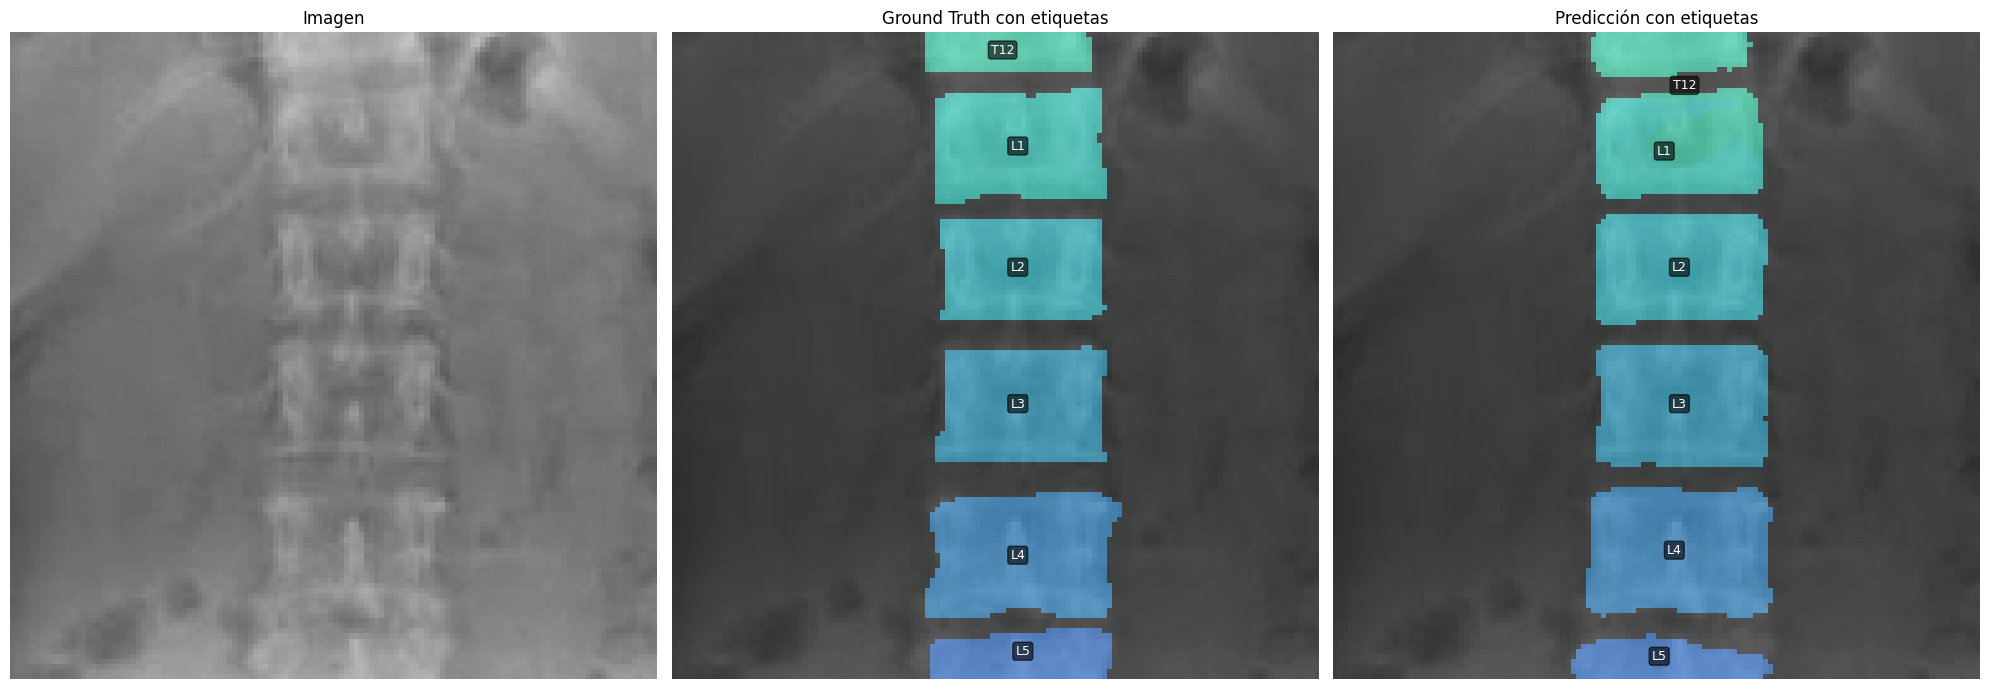

Dice Score promedio: 0.9462
Dice Score por clase: 
background 0.9815
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 1.0000
T6 1.0000
T7 1.0000
T8 1.0000
T9 1.0000
T10 1.0000
T11 1.0000
T12 0.6478
L1 0.7569
L2 0.9428
L3 0.9358
L4 0.9379
L5 0.8285
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


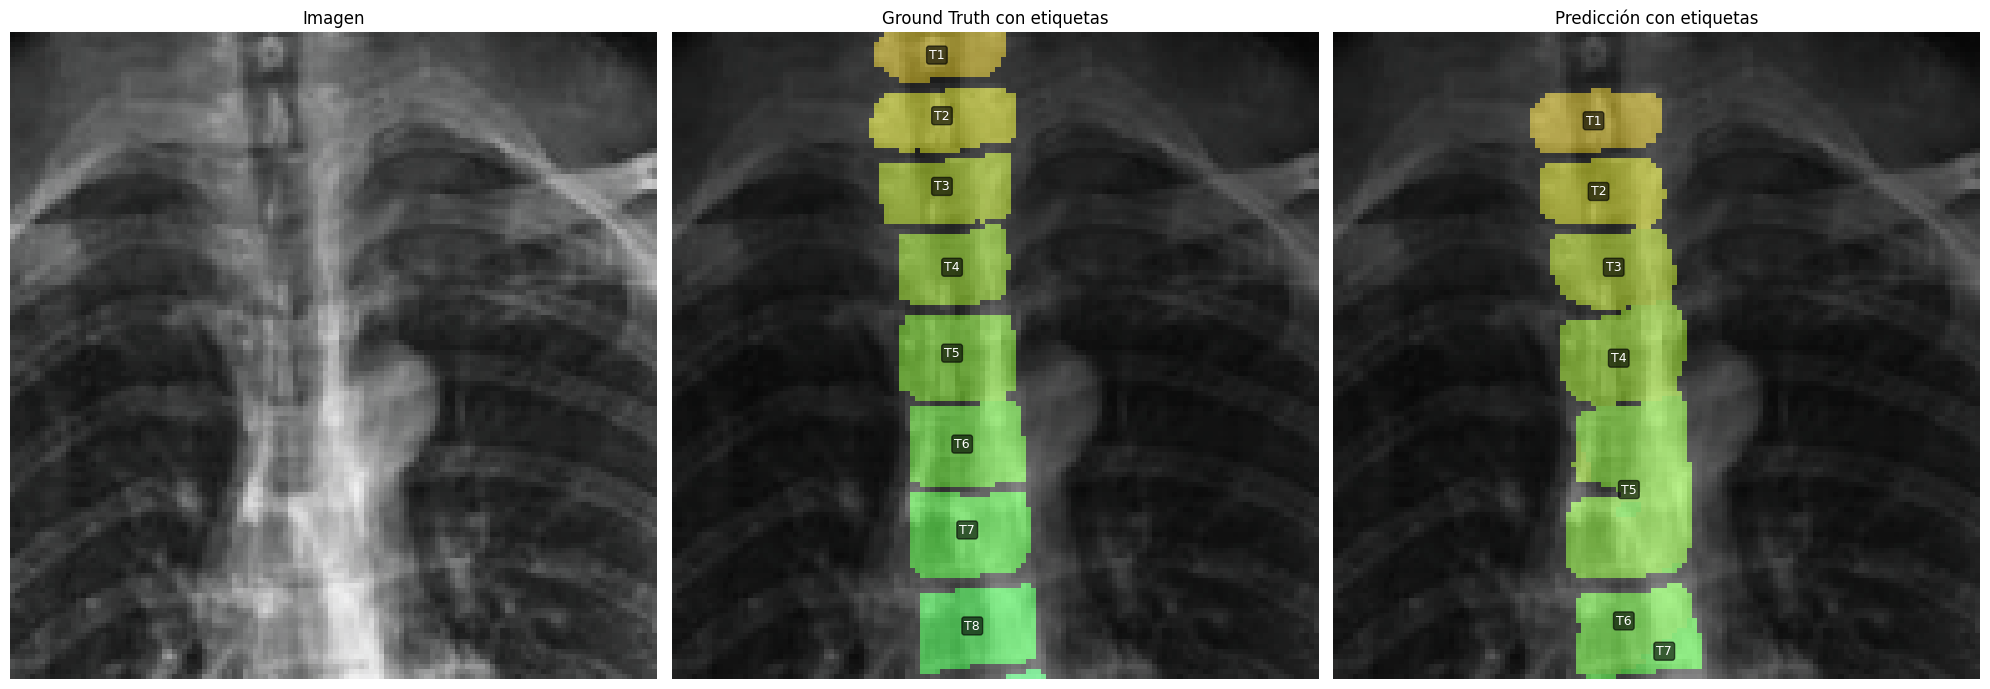

Dice Score promedio: 0.4989
Dice Score por clase: 
background 0.9779
T1 0.0000
T2 0.0000
T3 0.0000
T4 0.0000
T5 0.0018
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 1.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


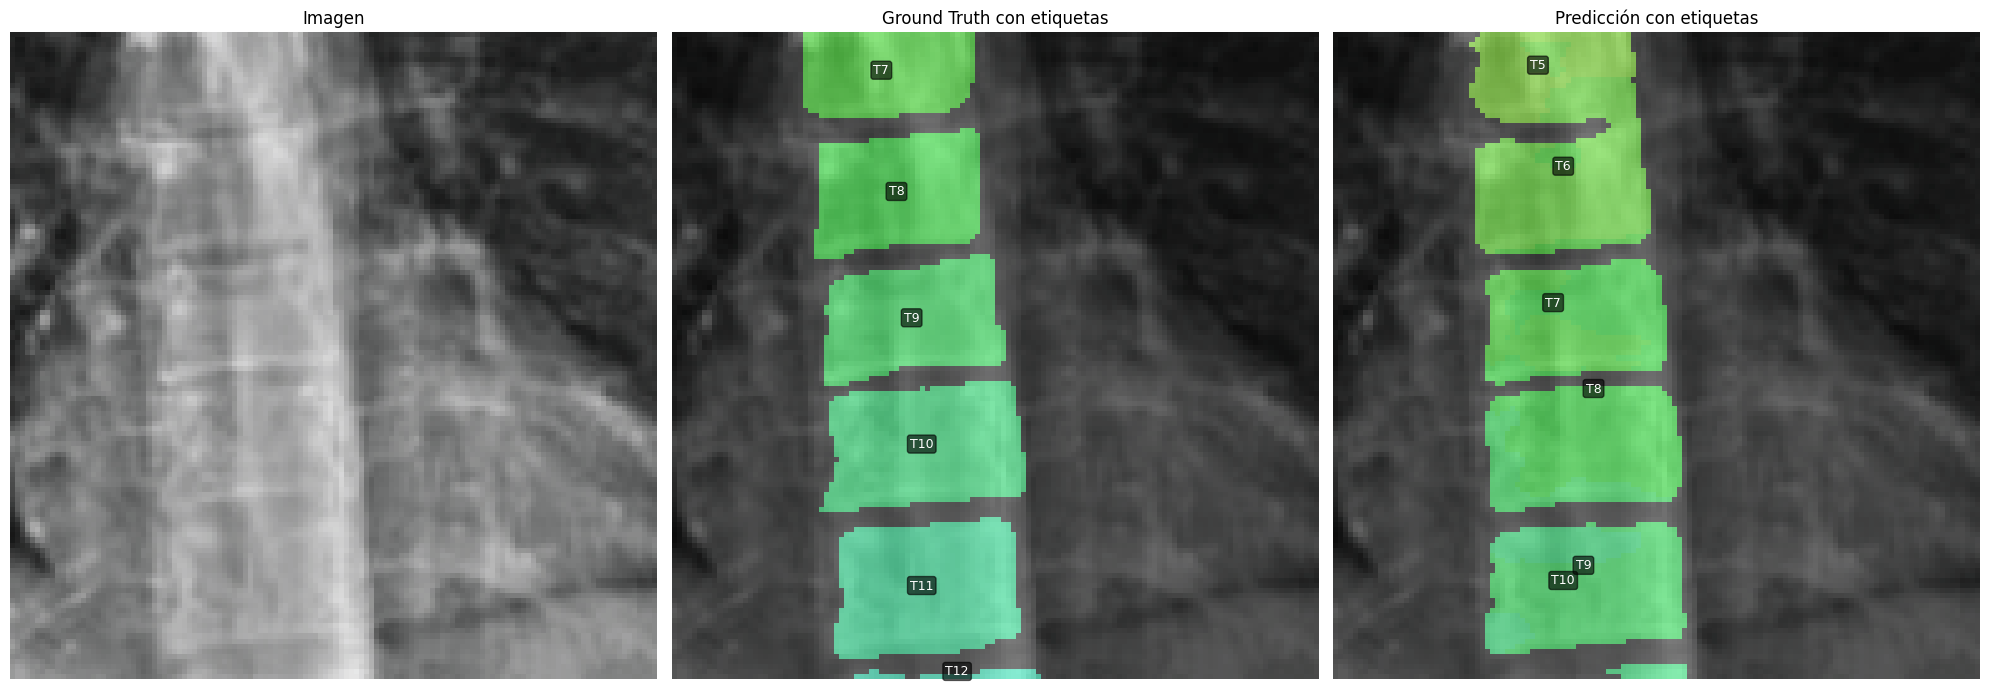

Dice Score promedio: 0.5544
Dice Score por clase: 
background 0.9800
T1 1.0000
T2 1.0000
T3 1.0000
T4 1.0000
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 0.0000
T12 0.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000
2
C:/Users/juanm/OneDrive/Documentos/MAIA/ProyectoMAIA\Scoliosis_Dataset/Normal/N_53.jpg


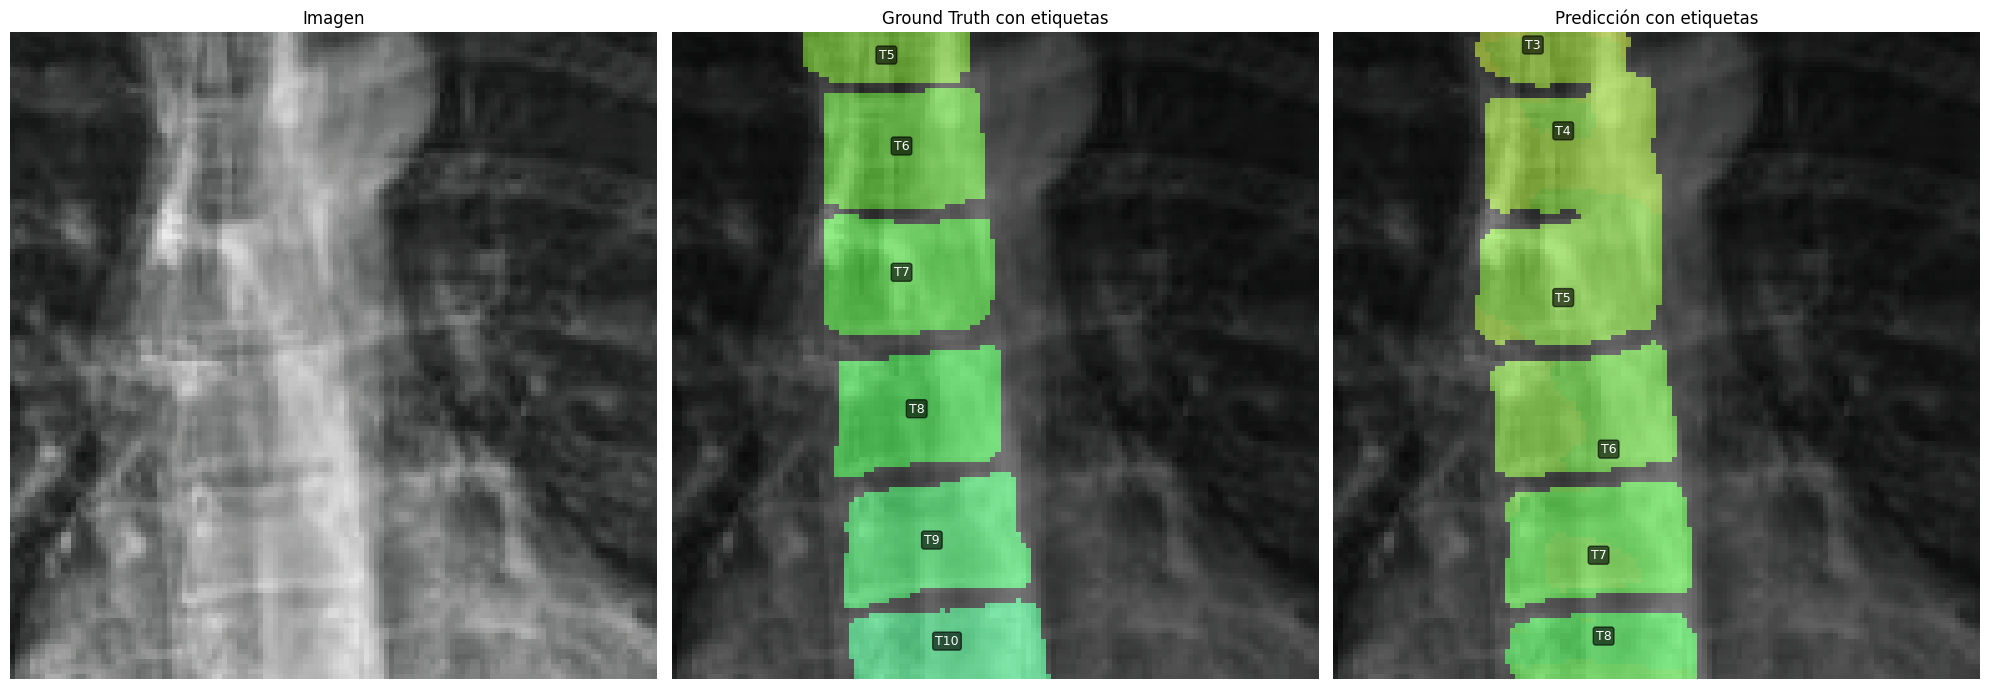

Dice Score promedio: 0.5542
Dice Score por clase: 
background 0.9751
T1 1.0000
T2 1.0000
T3 0.0000
T4 0.0000
T5 0.0000
T6 0.0000
T7 0.0000
T8 0.0000
T9 0.0000
T10 0.0000
T11 1.0000
T12 1.0000
L1 1.0000
L2 1.0000
L3 1.0000
L4 1.0000
L5 1.0000


In [39]:
import random
# Seleccionar un índice aleatorio del dataset de test
idx = 2
# print(idx)
for patch_idx in range(NUM_PATCHES):
    print(idx)
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=test_dataset,
        device=device,
        idx=idx,
        patch_idx = patch_idx,
        label_dict=dic_labels,
        alpha=0.45,
        min_pixels=20
    )

In [ ]:
import random
# Seleccionar un índice aleatorio del dataset de test
# idx = random.randint(0, len(test_dataset) - 1)
# print(idx)
for idx in range(len(test_dataset)):
    print(idx)
    show_gt_vs_pred_with_labels(
        model=model,
        dataset=test_dataset,
        device=device,
        idx=idx,
        patch_idx = random.randint(0, NUM_PATCHES-1),
        label_dict=dic_labels,
        alpha=0.45,
        min_pixels=20
    )

In [ ]:
# Visualización predicciones test con reconstrucción de máscara
model.eval()
for idx in range(len(test_img)):
        img_path = test_img[idx]
        mask_path = test_mask[idx]
        image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        image = test_transforms(image=image)['image']
        pred_mask = patch_inference(model, image, mask, patch_area=best_crop, stride=STRIDE, sigma=SIGMA)
        # print(image.shape)
        show_gt_vs_pred_with_labels_images(
            image,
            mask,
            pred_mask,
            label_dict=dic_labels,
            alpha=0.45,
            min_pixels=20
        )


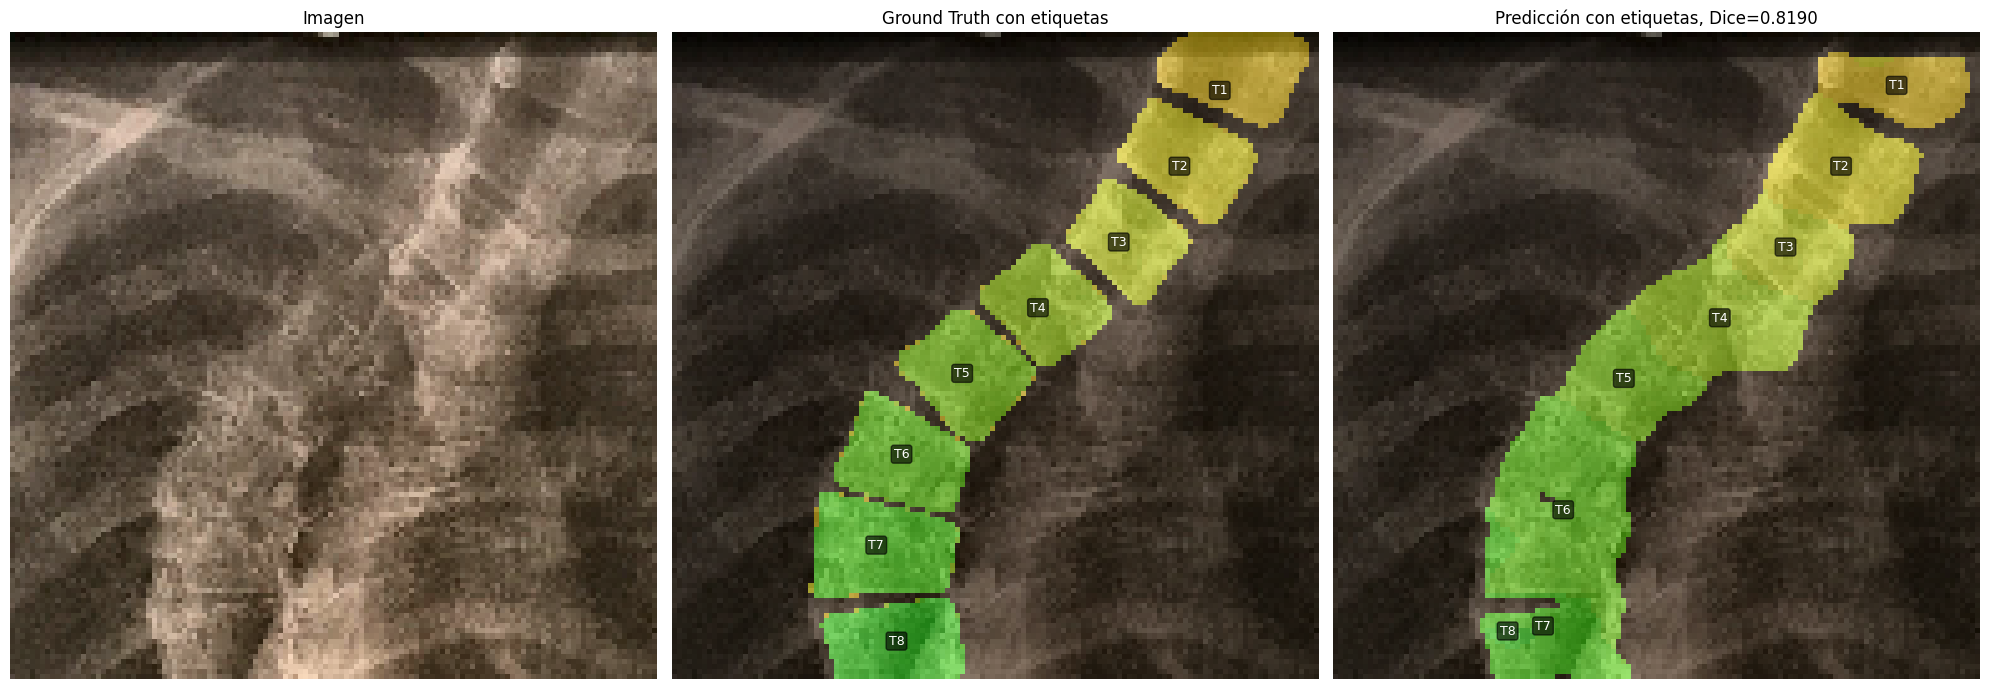

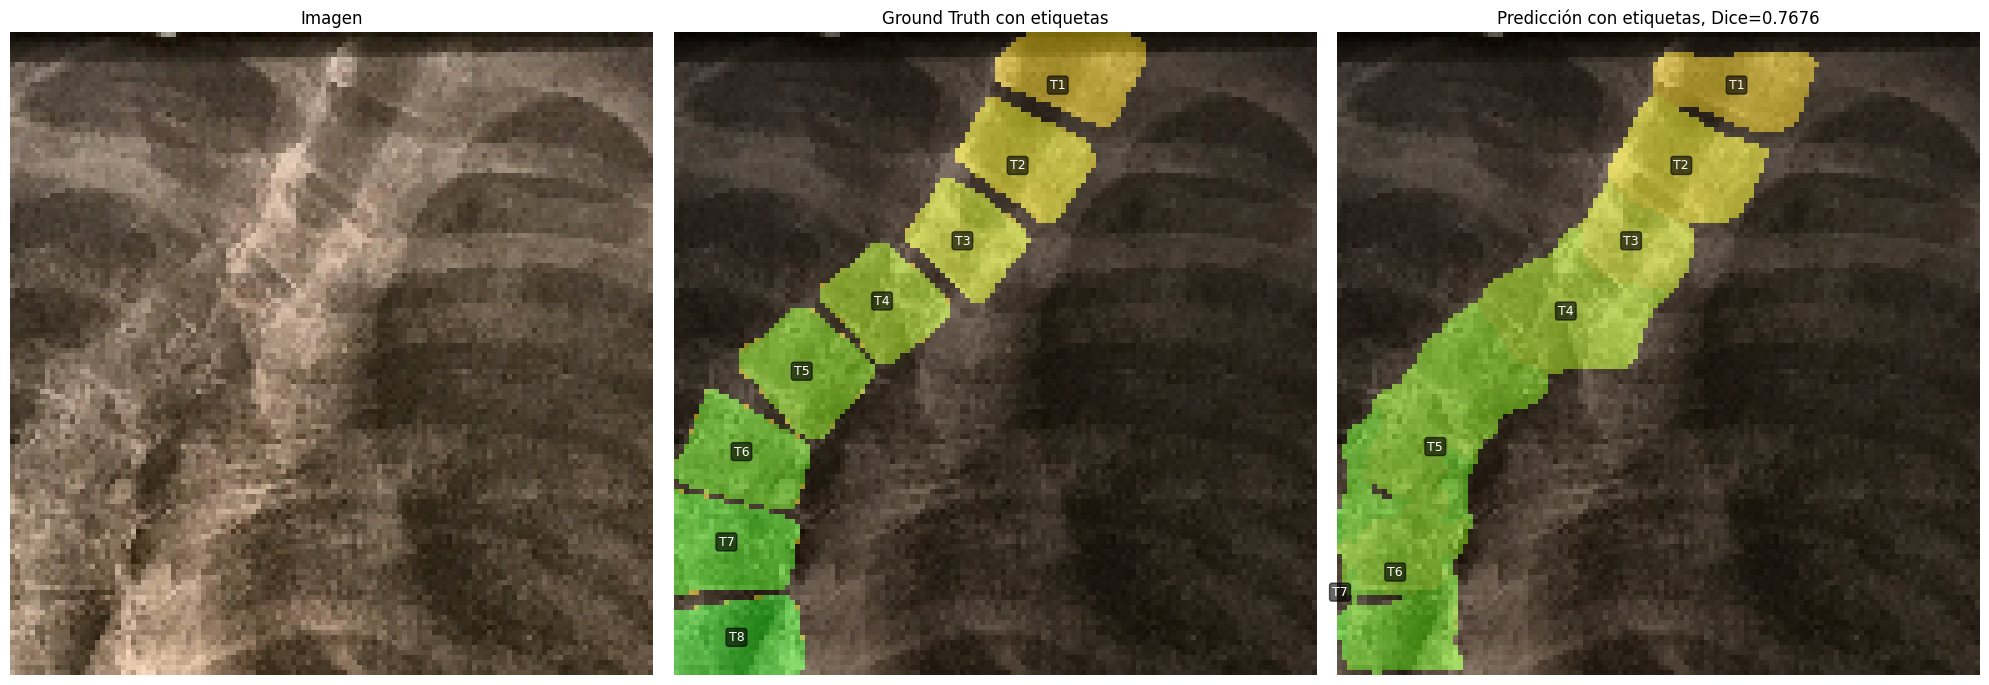

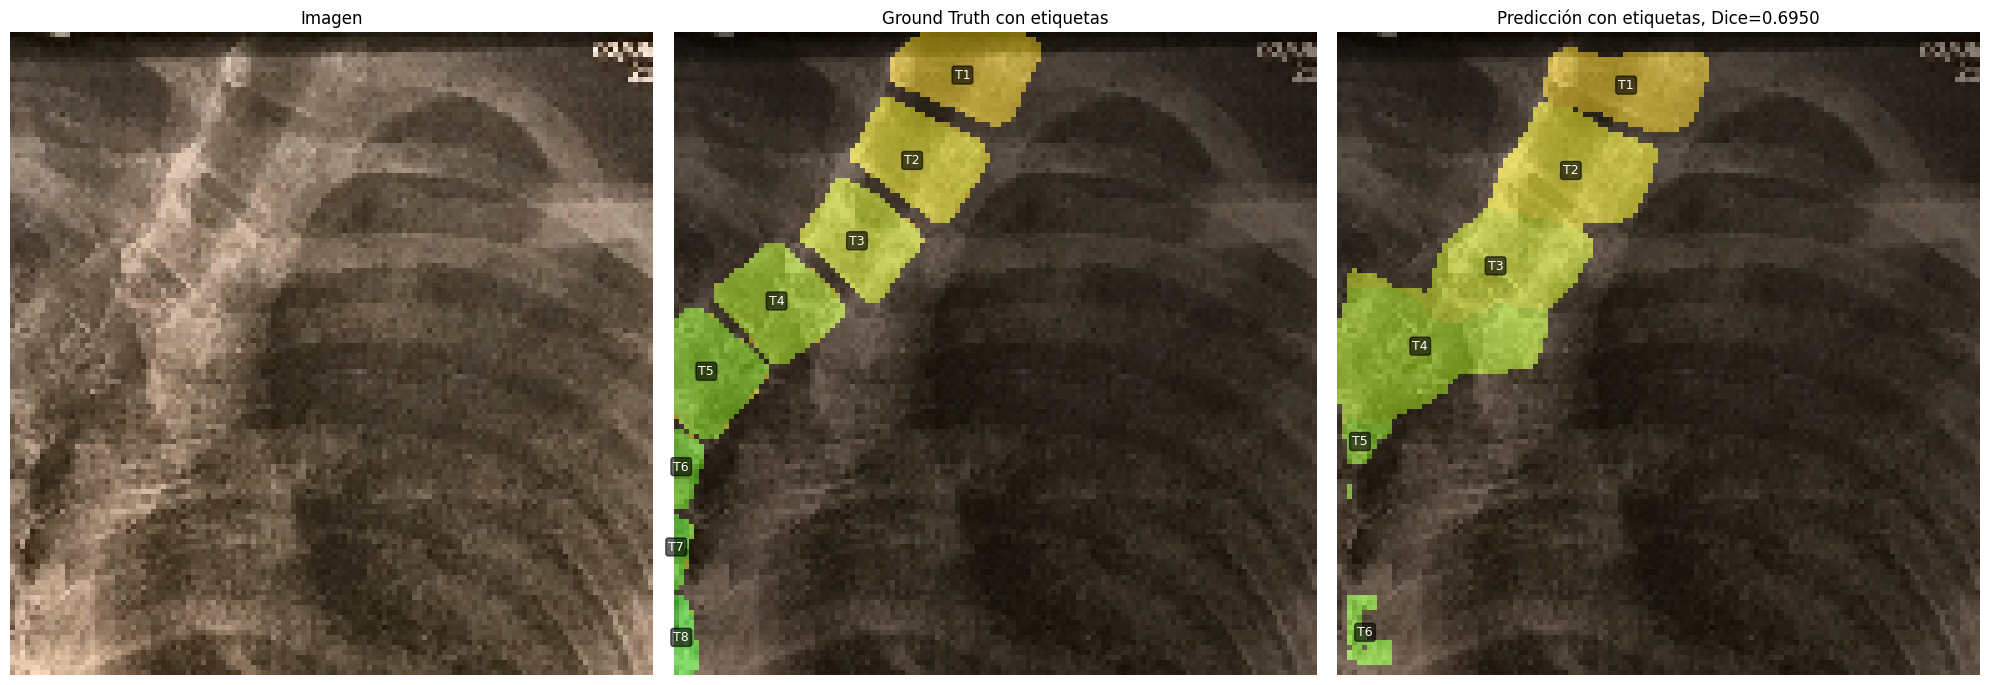

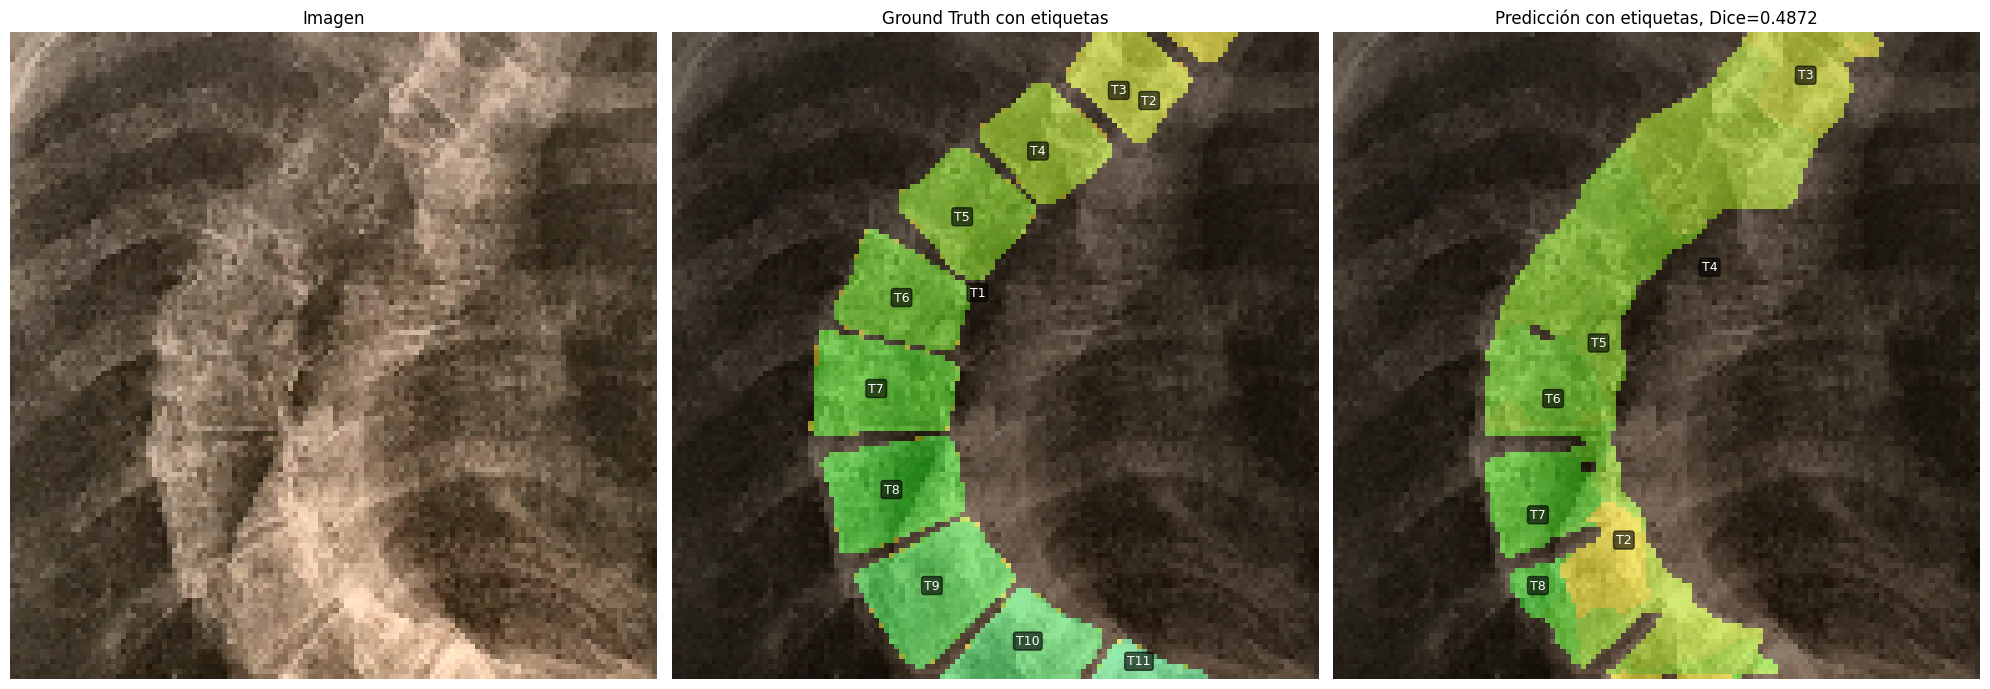

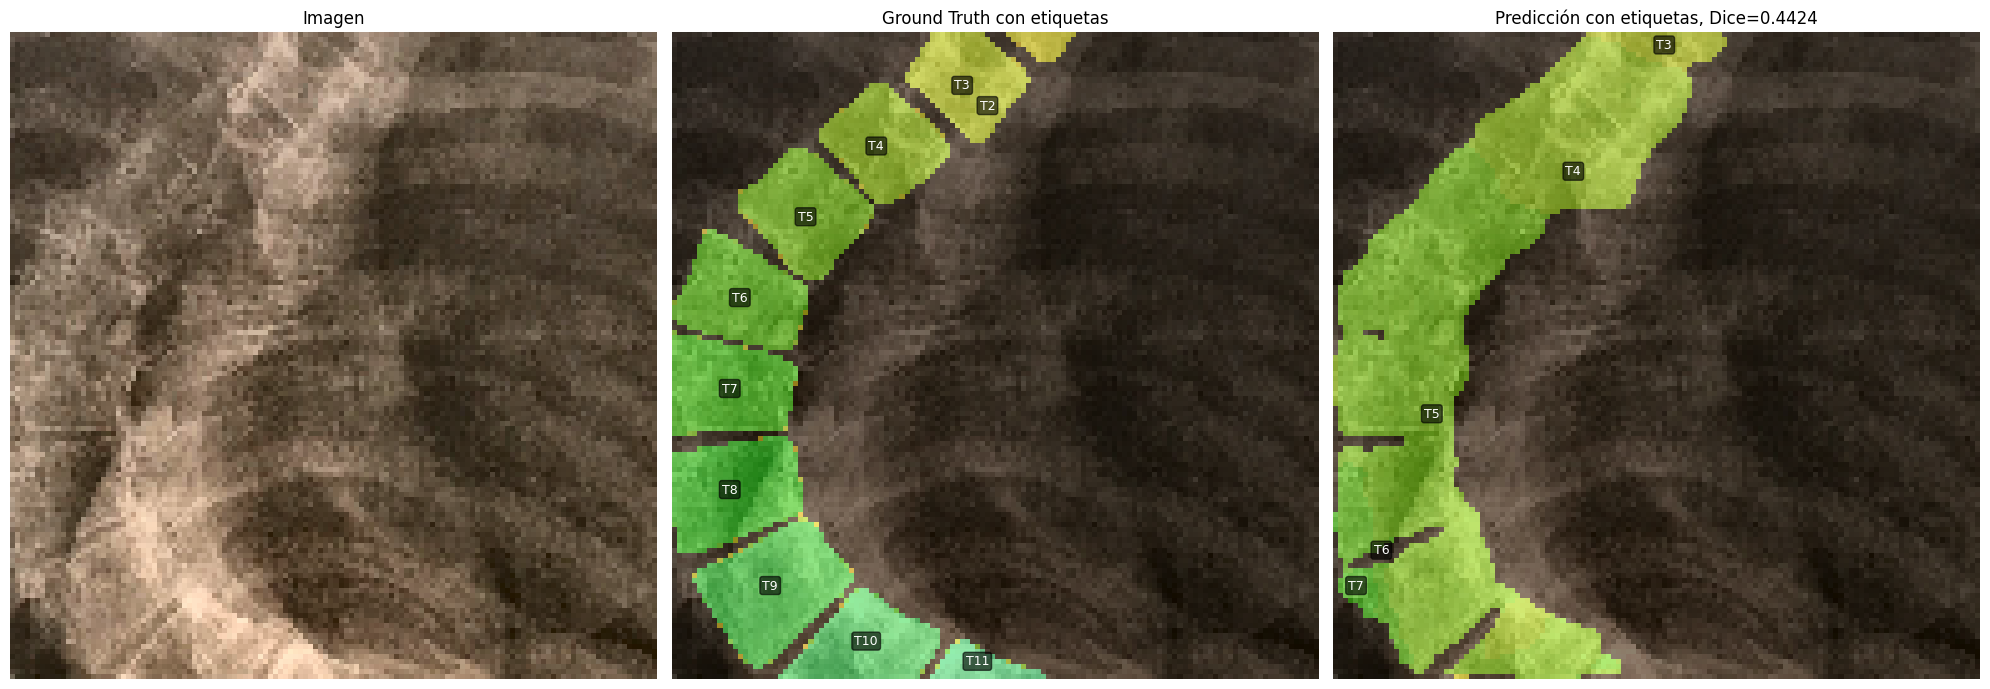

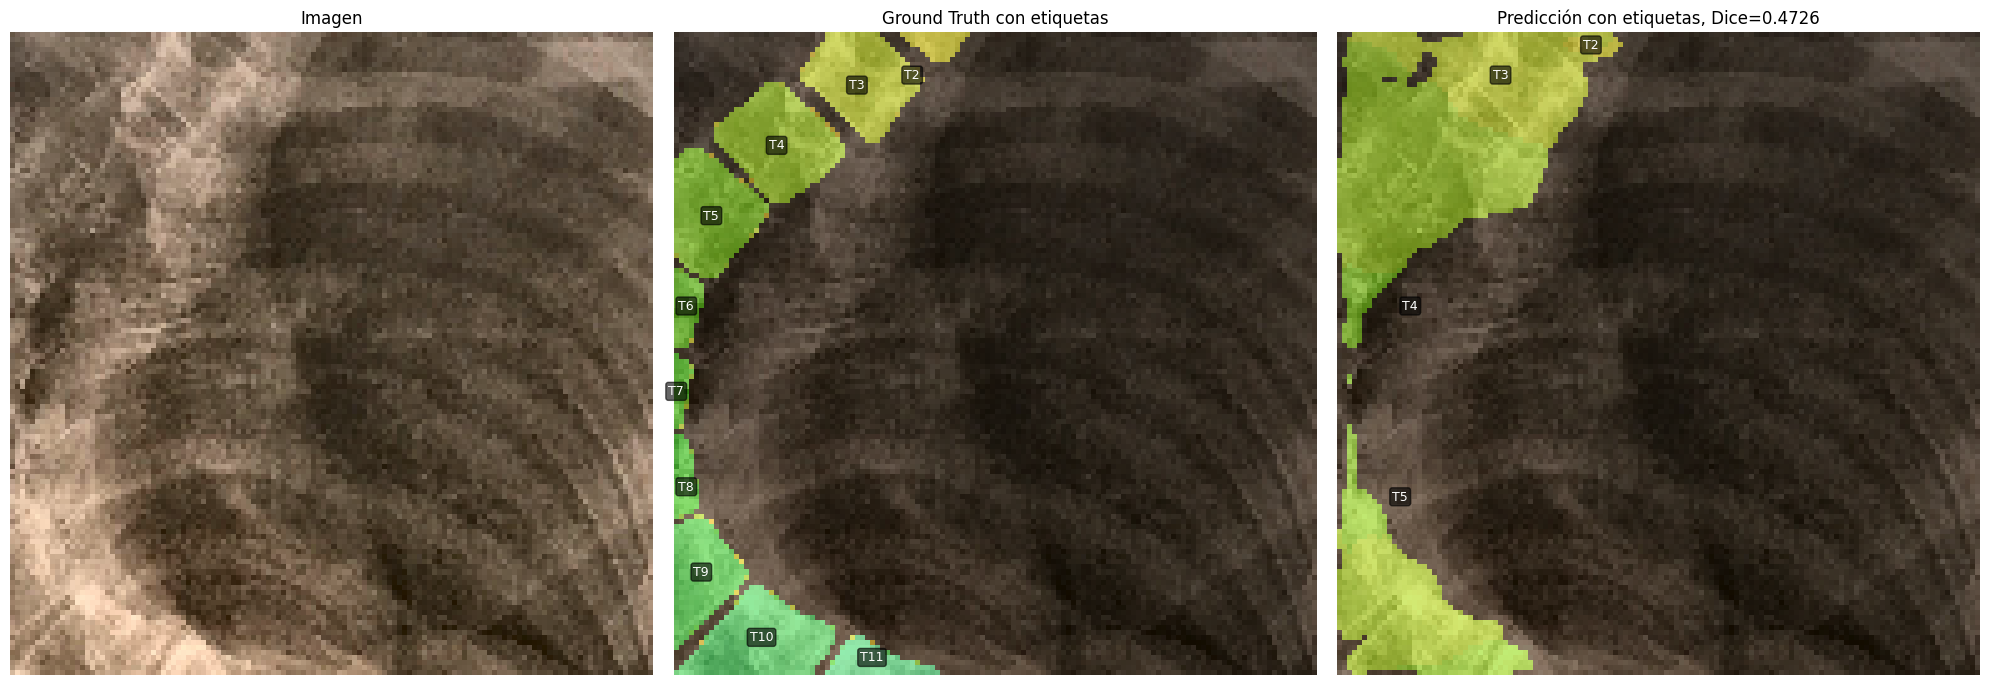

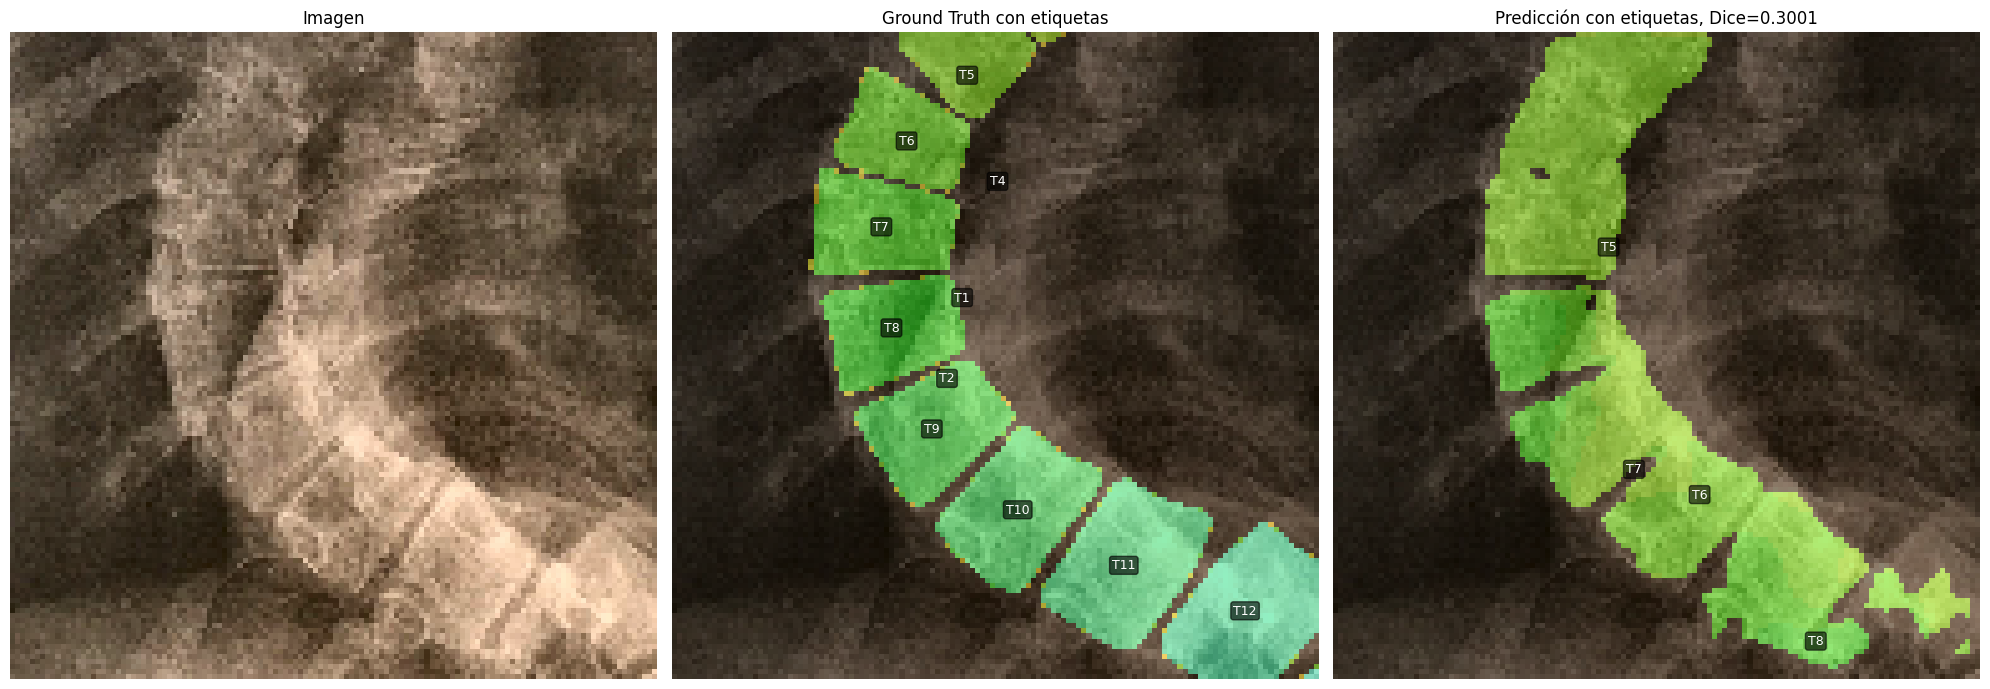

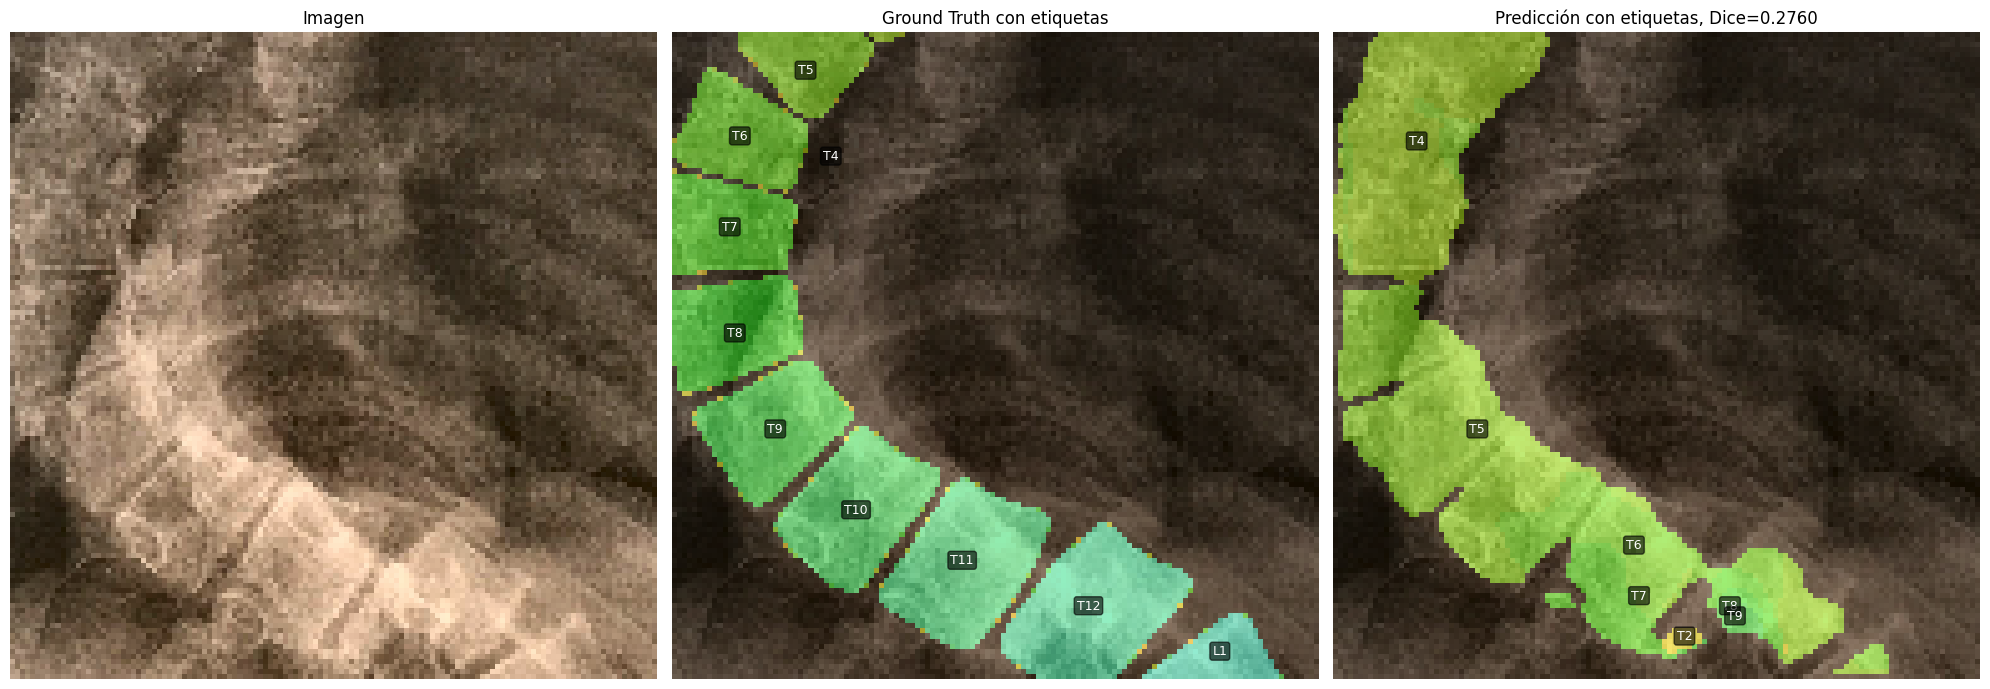

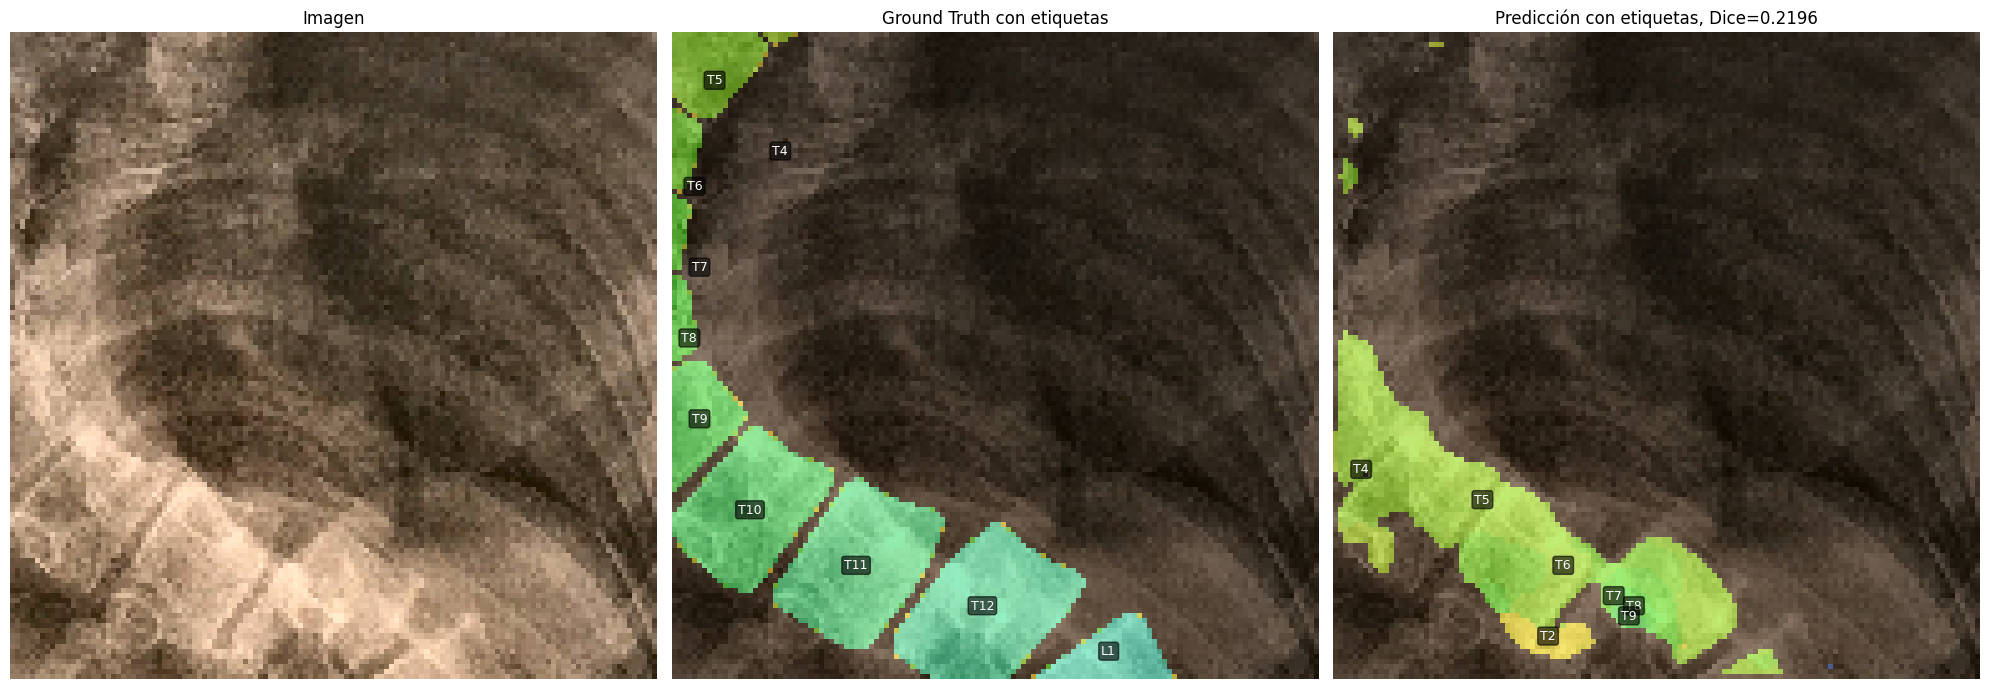

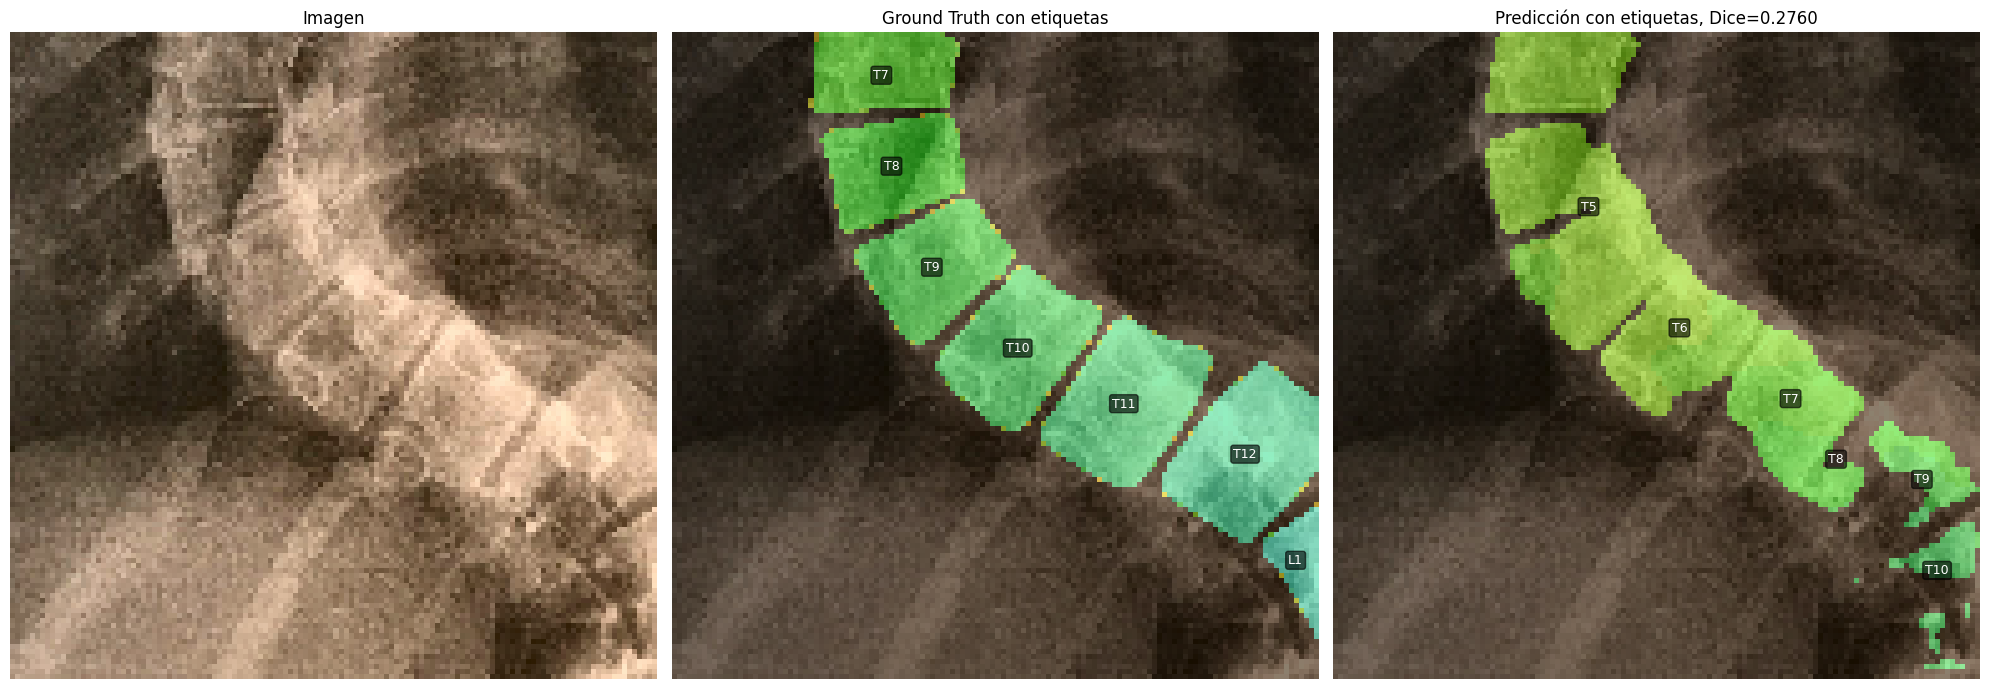

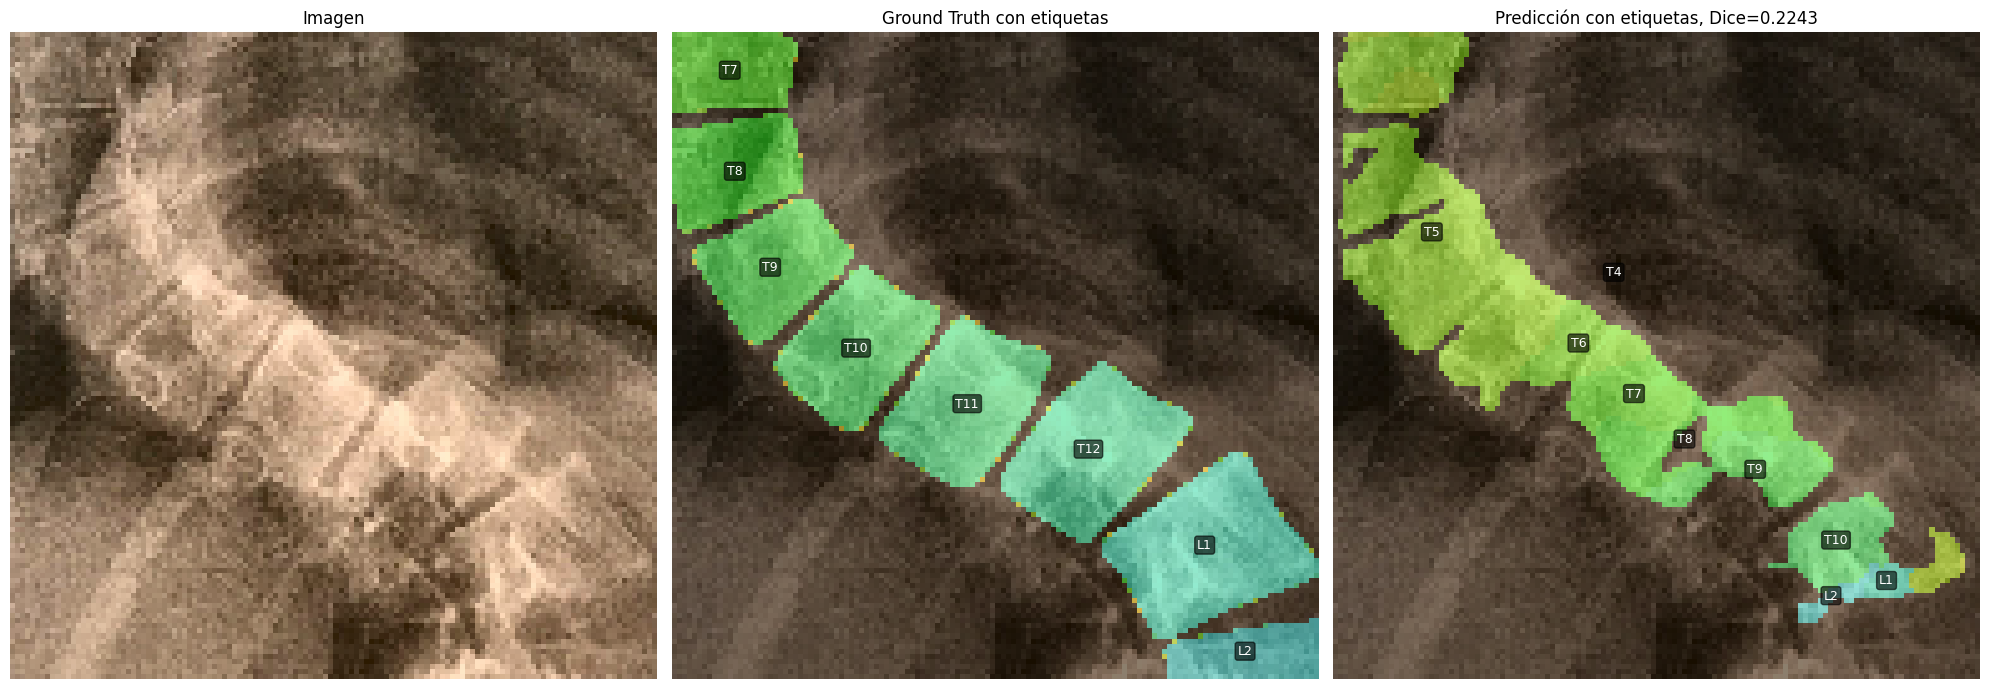

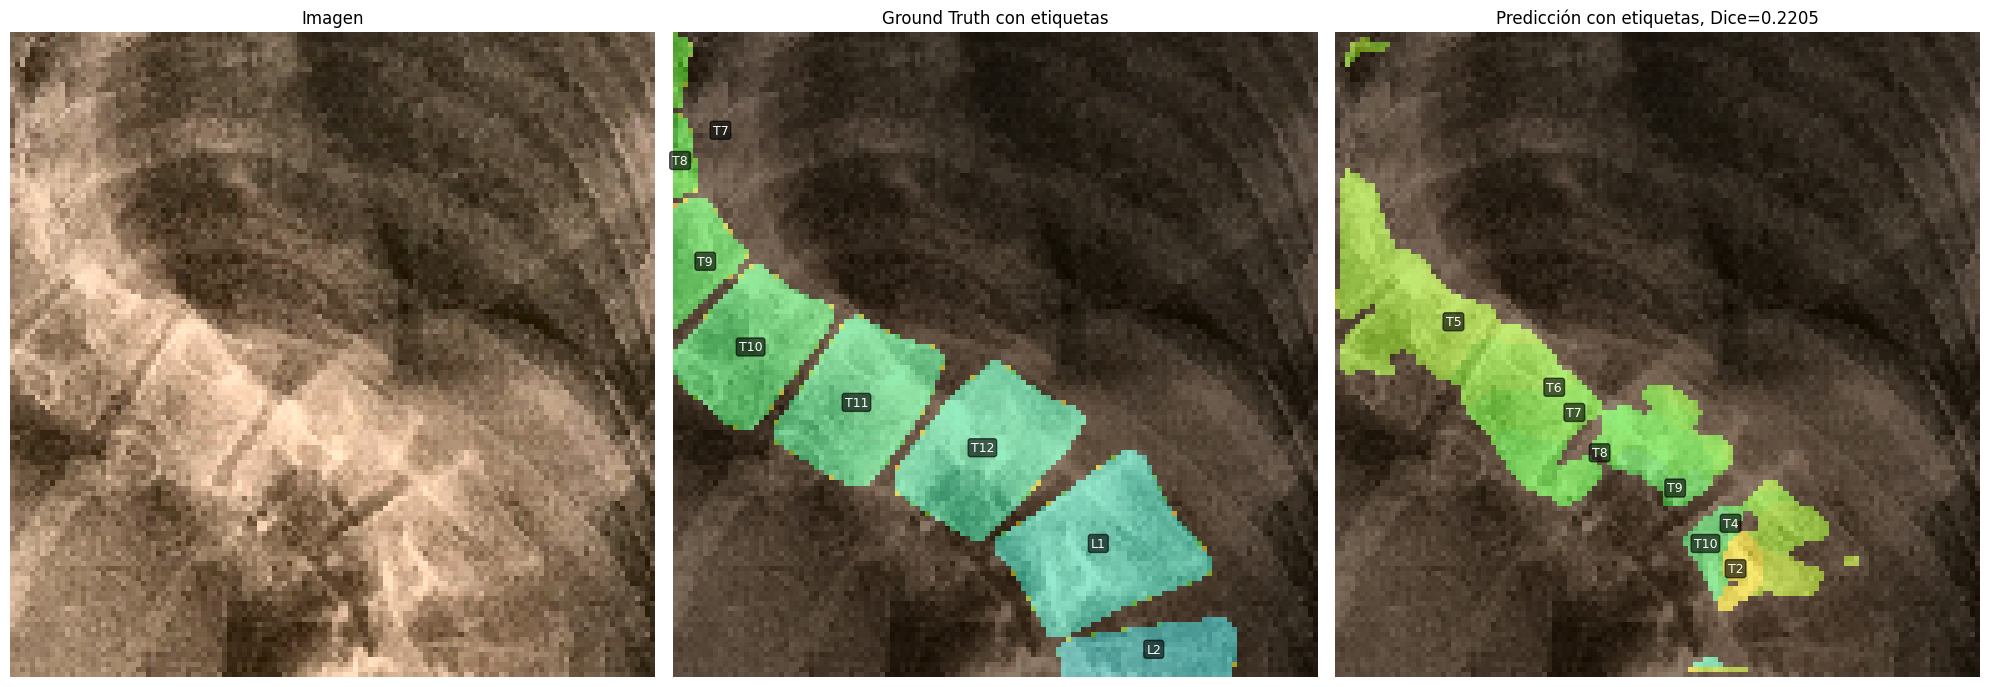

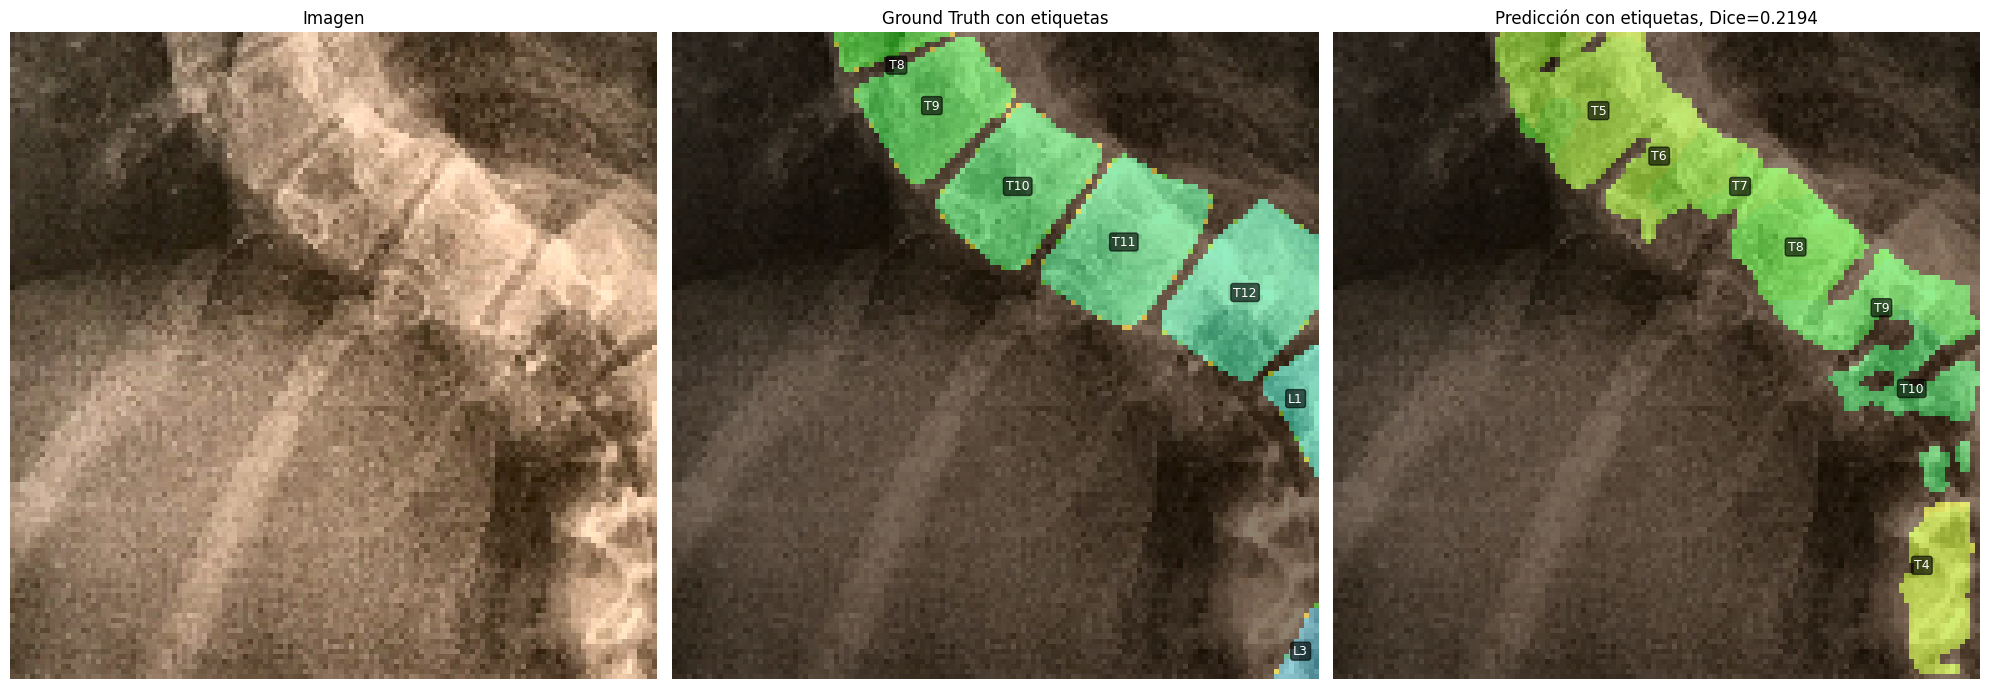

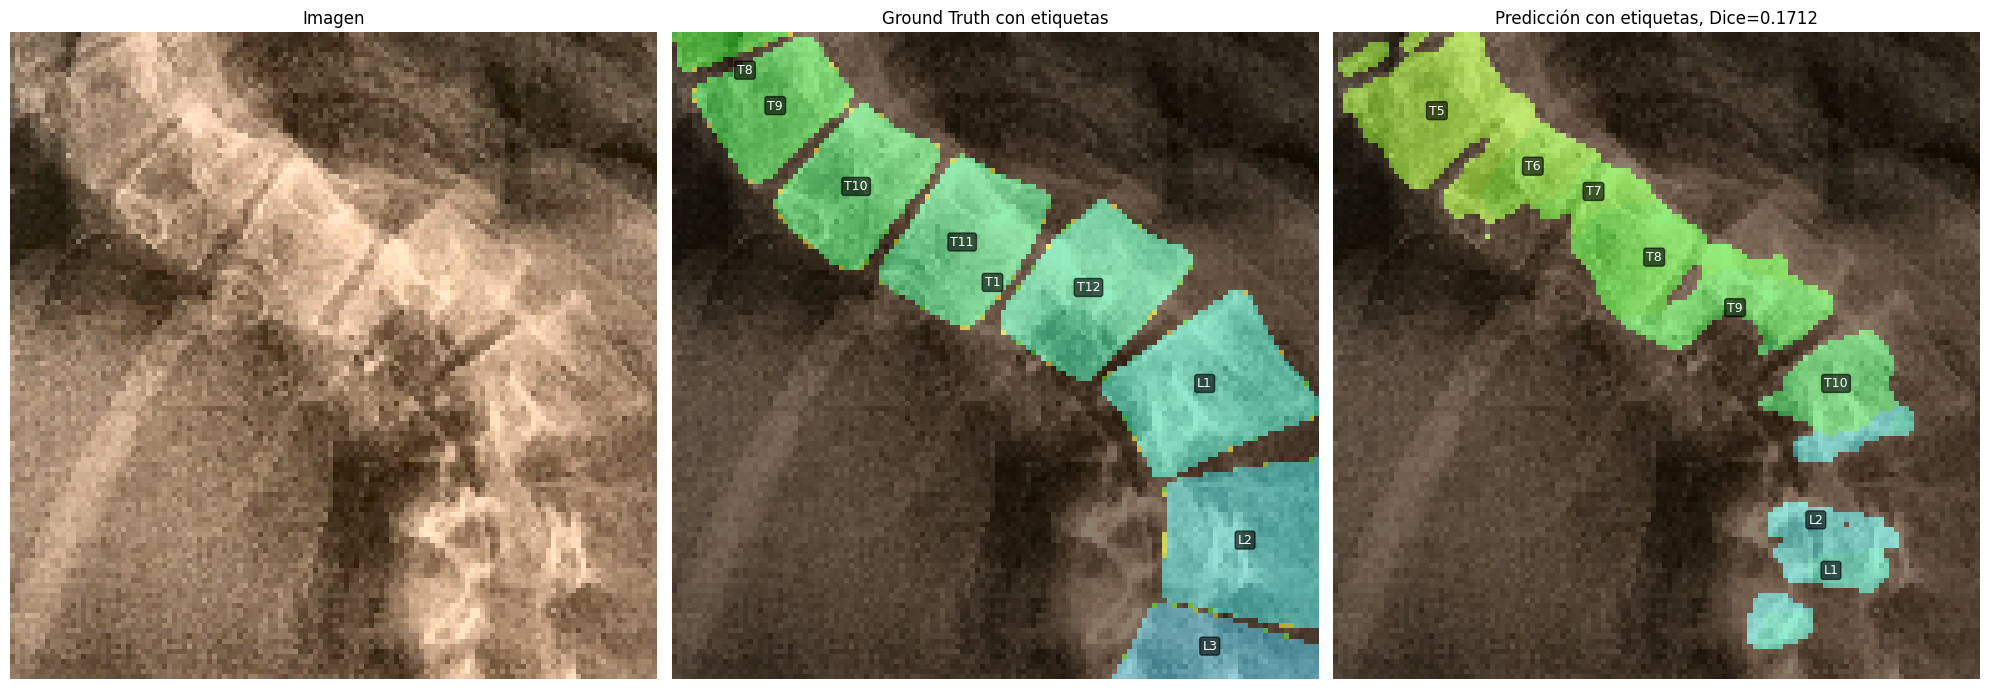

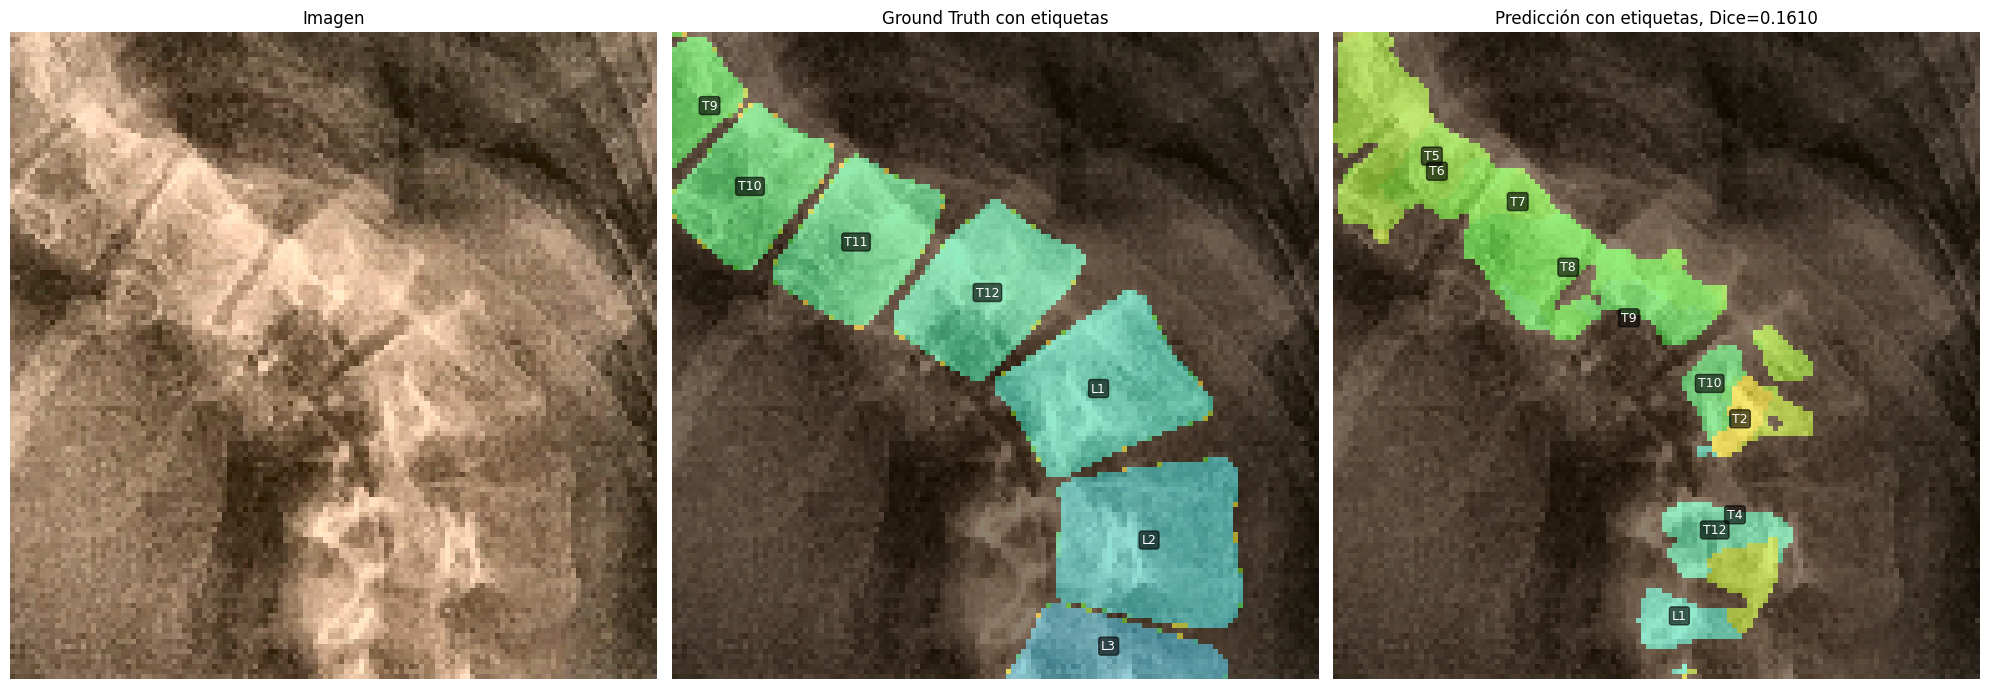

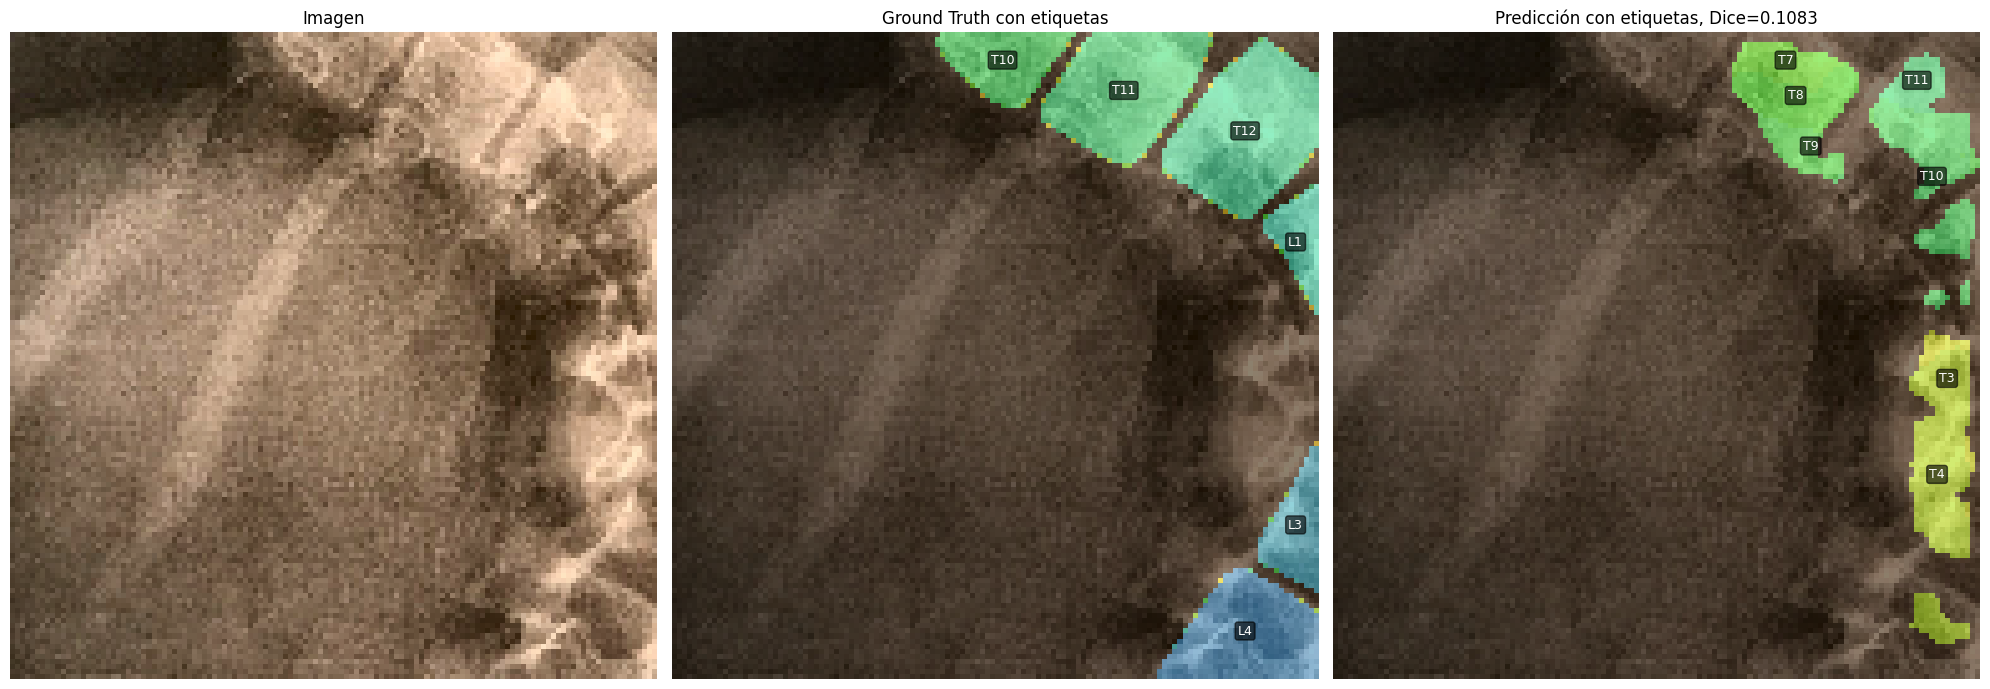

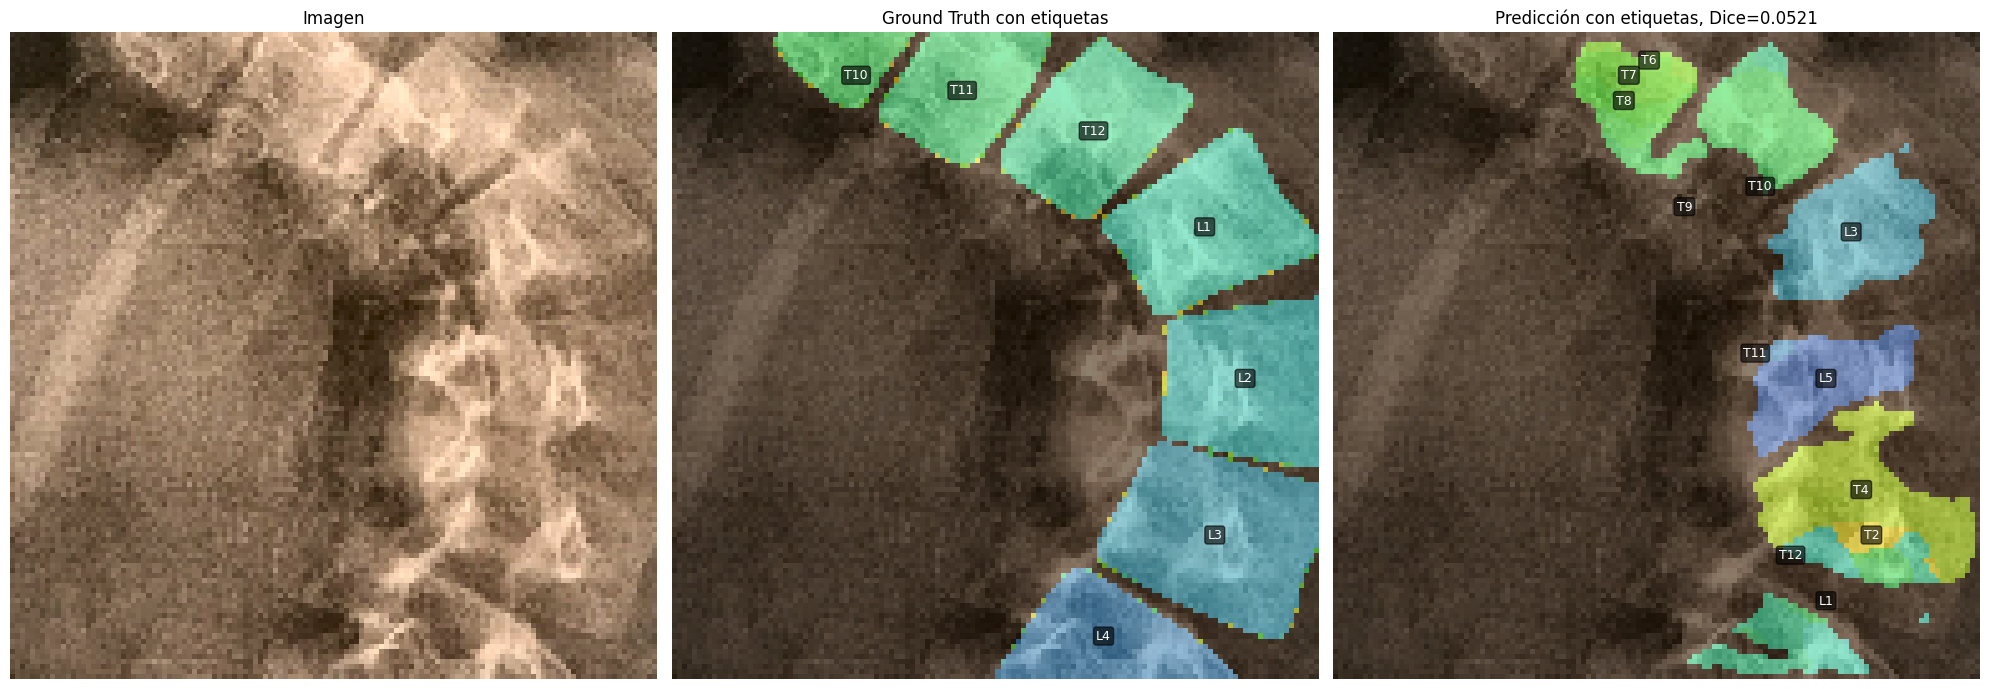

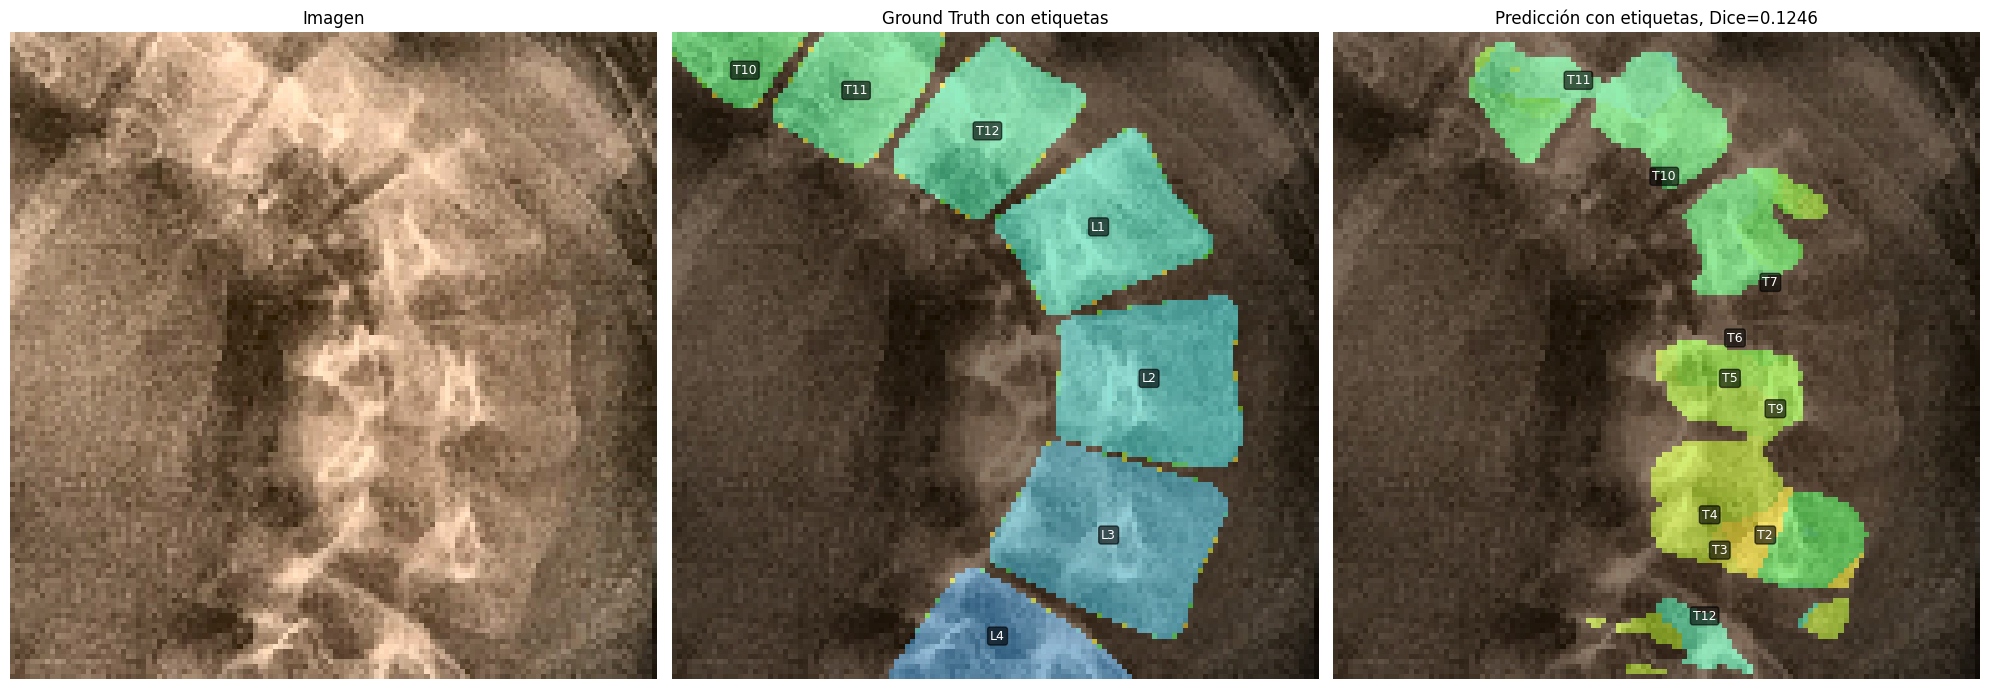

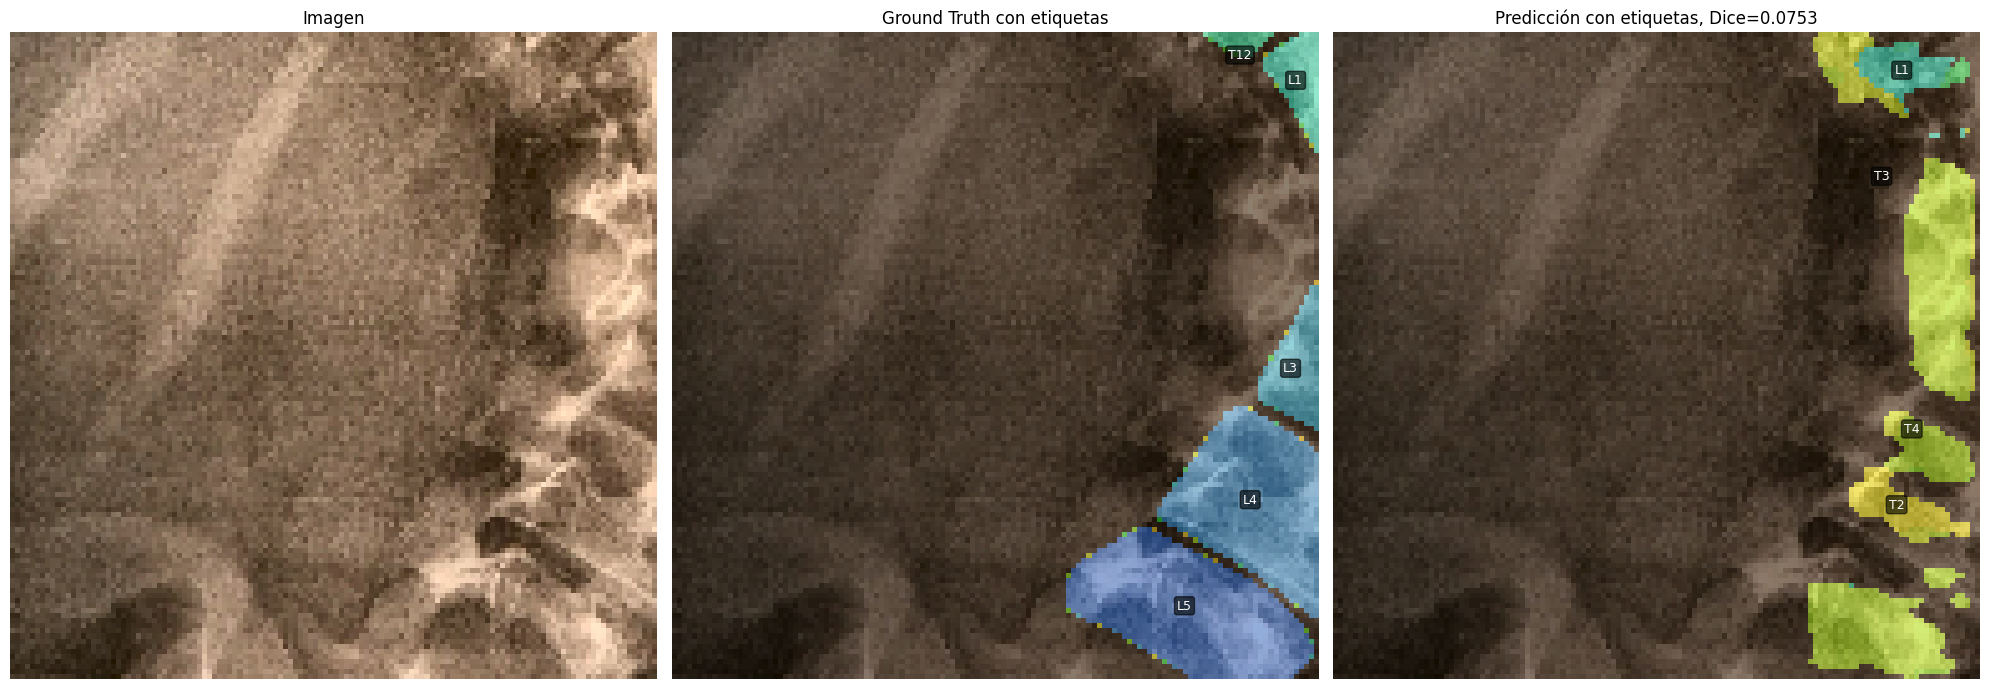

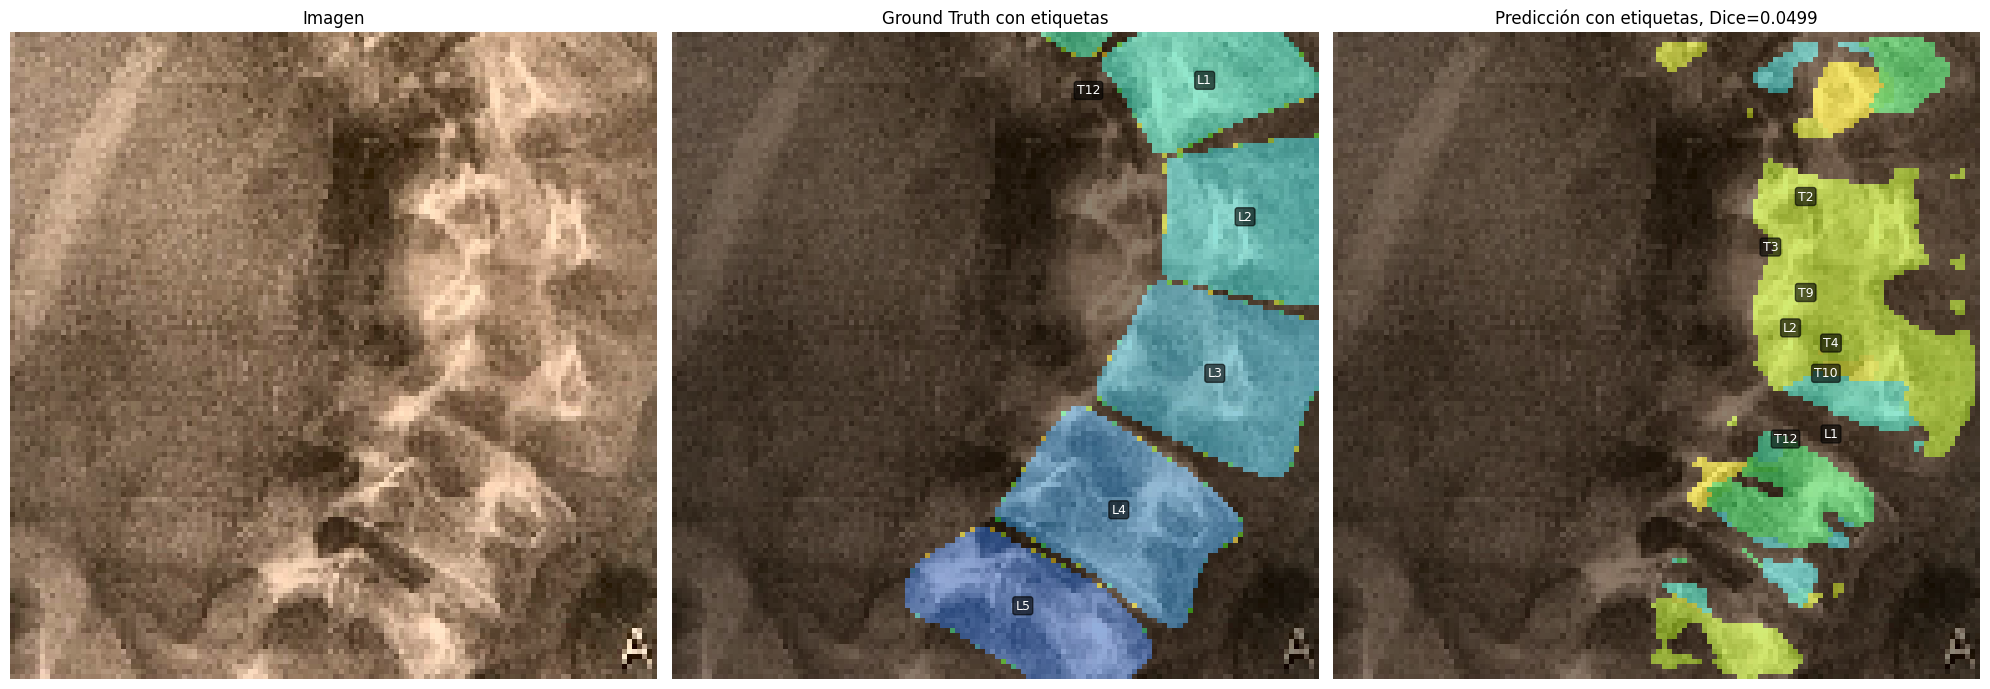

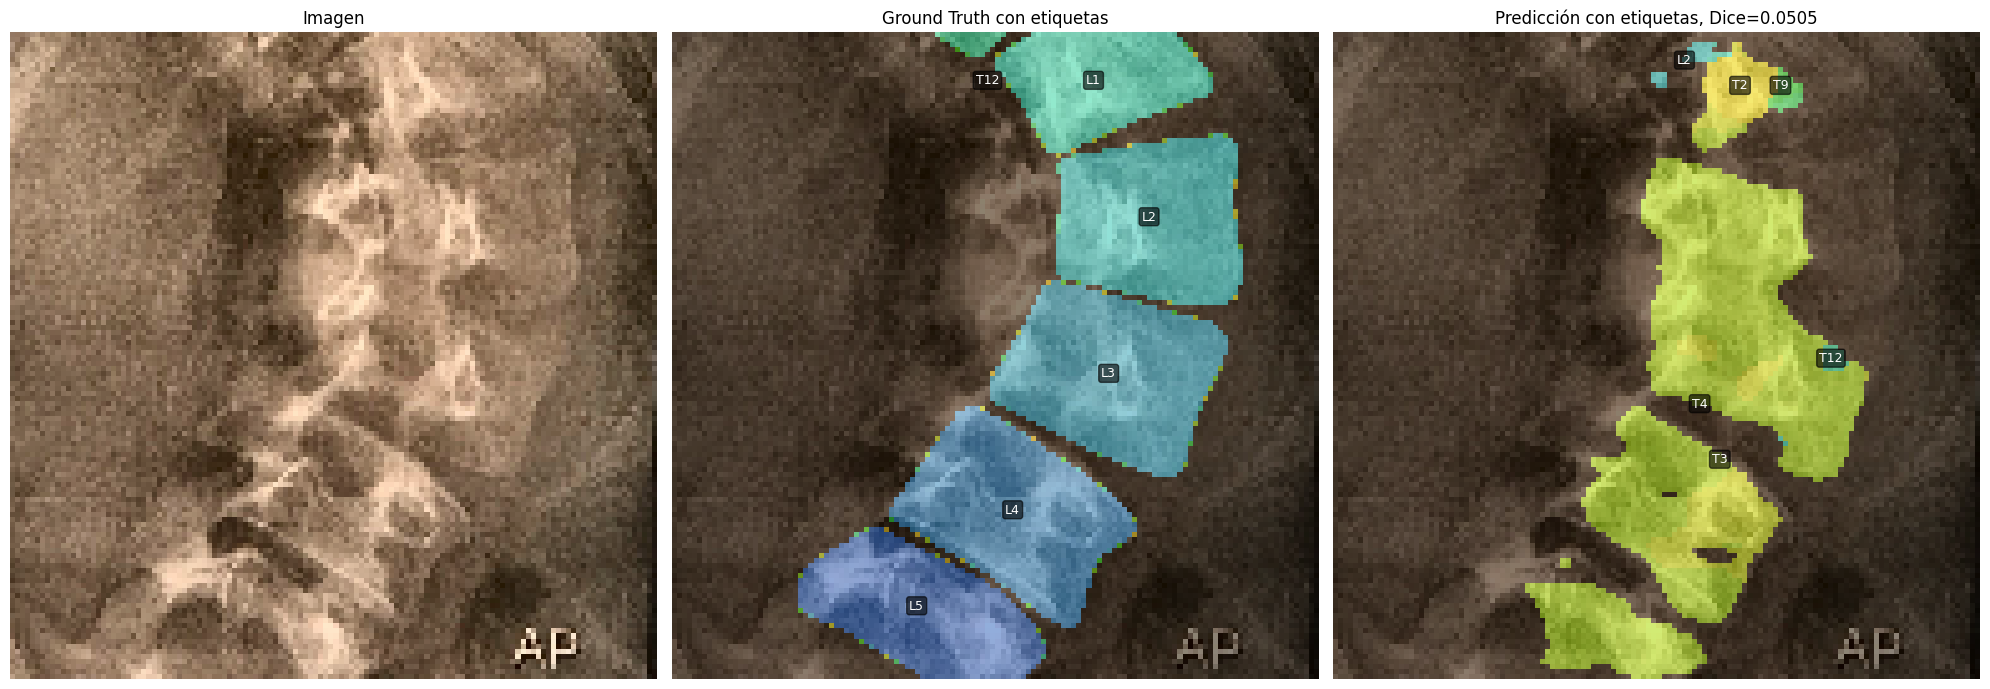

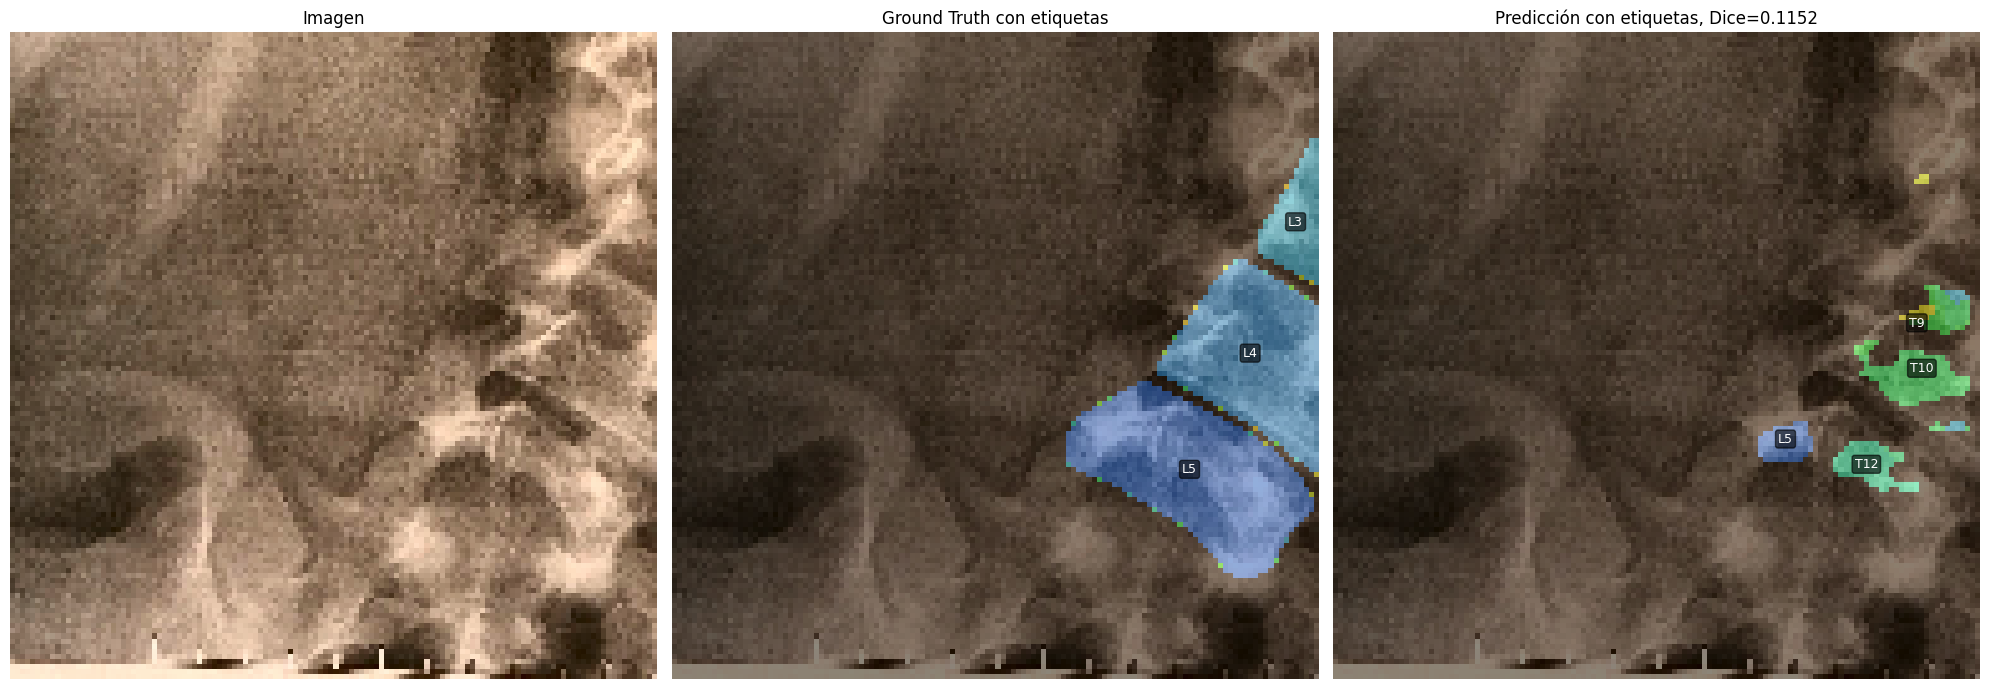

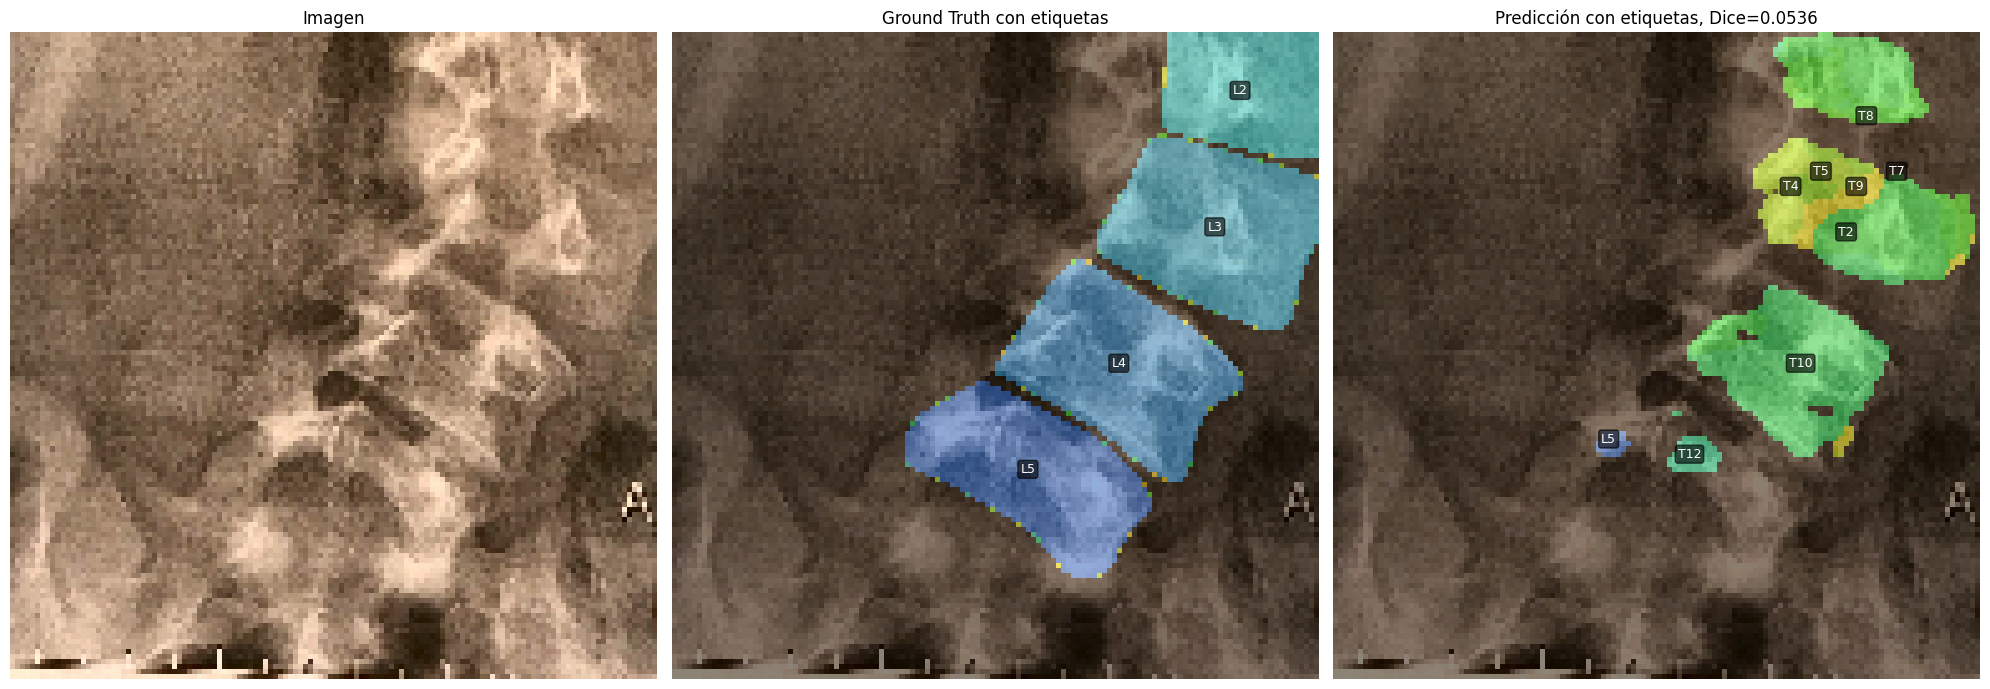

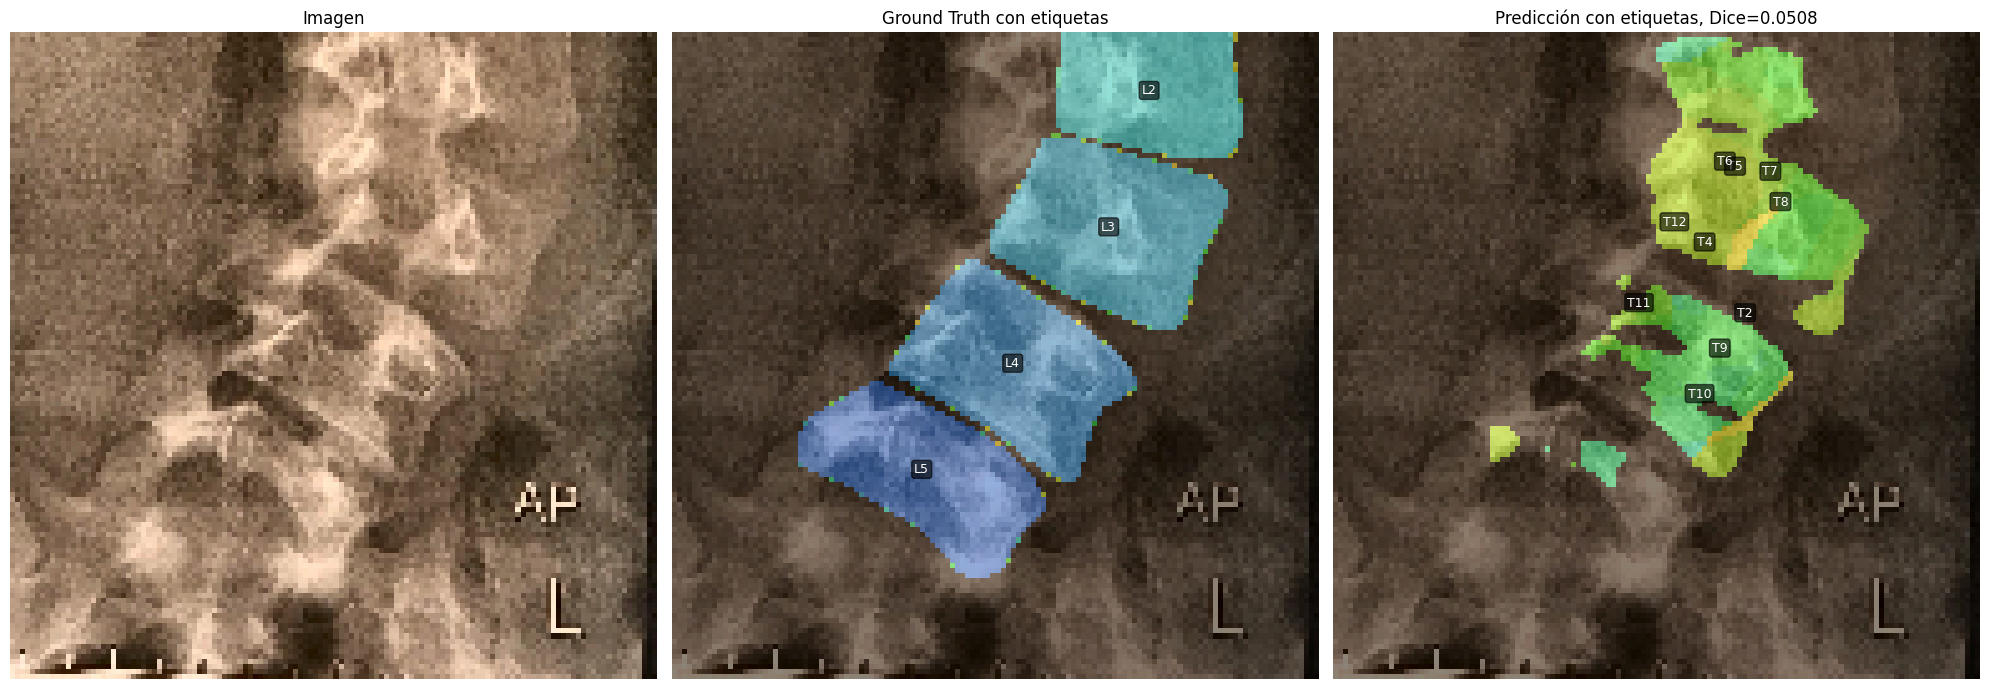

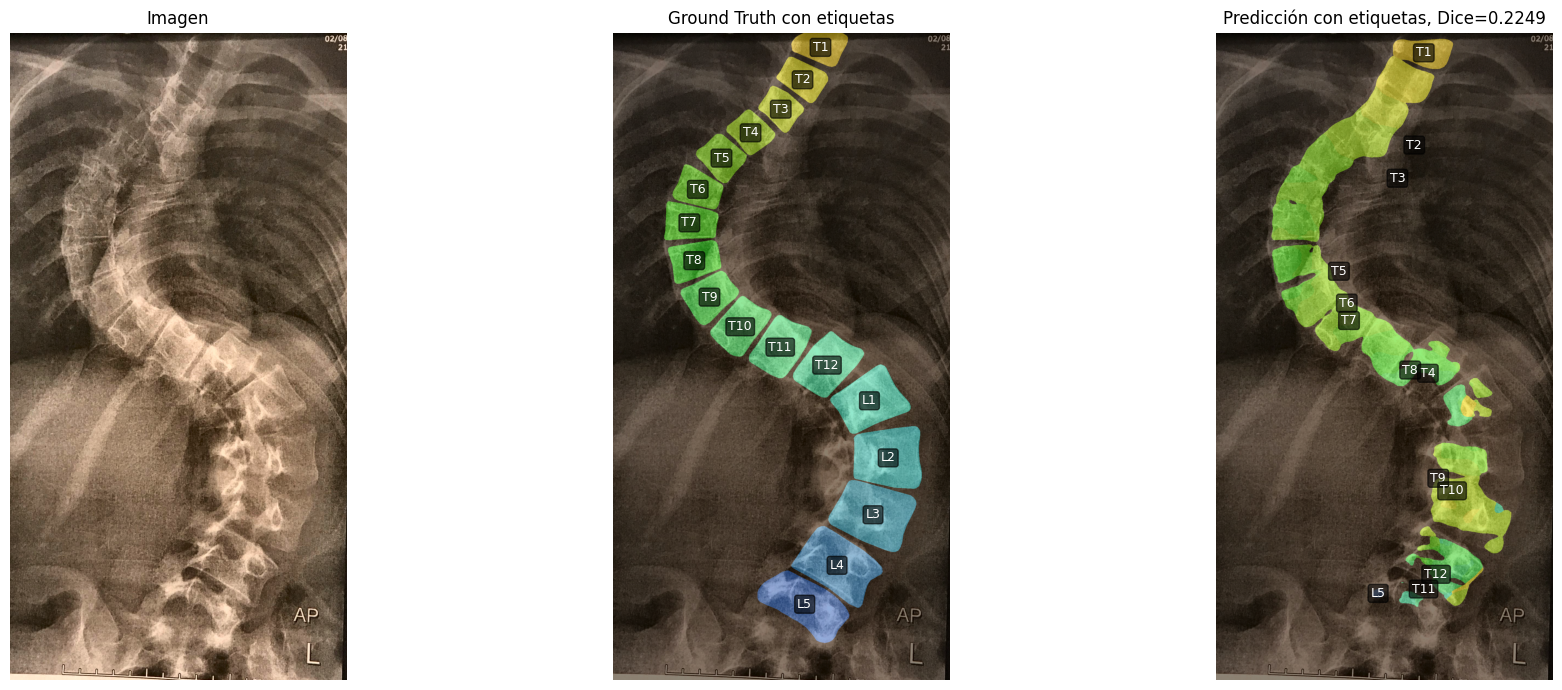

In [168]:
model.eval()
idx=34
img_path = test_img[idx]
mask_path = test_mask[idx]
image = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
image = test_transforms(image=image)['image']
pred_mask = patch_inference(model, image, mask, patch_area=best_crop, stride=STRIDE, sigma=SIGMA, show_patches=True)
# print(image.shape)
show_gt_vs_pred_with_labels_images(
    image,
    mask,
    pred_mask,
    label_dict=dic_labels,
    alpha=0.45,
    min_pixels=20
)